# AI-Generated News Text Detection: Generalisation to Unseen LLMs

**Research question (proposed):** Does a supervised detector trained to distinguish human-written from AI-generated news text generalise to an LLM it has never seen during training?

Dataset: *A Comprehensive Dataset for Human vs. AI Generated Text Detection* (Roy et al., 2025, arXiv:2510.22874), Hugging Face: `gsingh1-py/train`, CC BY 4.0.

## Notebook structure
1. **Part 1: Setup, data loading and data inspection**
2. **Part 2: Cleaning, topic alignment and grouped split**
3. **Part 3: Evaluation protocol and baselines (majority, TF-IDF + Logistic Regression)**
4. **Part 4: Generalisation experiments with the TF-IDF baseline (leave-one-generator-out, train on one LLM, input length)**
5. **Part 5: DistilBERT detector with a hand-written PyTorch training loop (GPU)**
6. Part 6: Error analysis *(to be added)*

---

# Part 1: Setup, data loading and data inspection

Goal: understand the raw data *before* any modelling decision. We check:
1. the structure of the dataset (columns, missing values);
2. how the wide table (1 row = 1 prompt, 7 texts) maps to our learning samples (1 row = 1 text);
3. text lengths per source (risk: length shortcut);
4. duplicates and very short texts (data quality);
5. formatting artefacts (e.g. titles, markdown) that could let a detector "cheat";
6. what 7 texts of the same prompt look like (why we must split by prompt).

## 1. Environment setup

In [1]:
# Colab already has pandas/numpy; `datasets` is the Hugging Face library used to download the data.
!pip install -q datasets

import random
import re
import numpy as np
import pandas as pd
from datasets import load_dataset

SEED = 42                      # fixed seed so every sampling step is reproducible
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

## 2. Load the raw dataset

The dataset has a single `train` split (the authors did not provide train/val/test splits,
so we will create our own later, grouped by prompt).

In [2]:
raw = load_dataset("gsingh1-py/train", split="train")
df_wide = raw.to_pandas()

print("Shape (rows, columns):", df_wide.shape)
print("\nColumns:")
for c in df_wide.columns:
    print("  ", repr(c))

Repo card metadata block was not found. Setting CardData to empty.


train.csv: reconstructing file:   0%|          |  0.00B /  161MB            

train.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7321 [00:00<?, ? examples/s]

Shape (rows, columns): (7321, 8)

Columns:
   'prompt'
   'Human_story'
   'gemma-2-9b'
   'mistral-7B'
   'qwen-2-72B'
   'llama-8B'
   'accounts/yi-01-ai/models/yi-large'
   'GPT_4-o'


### 2.1 Rename columns to short, consistent names

The original column names are long (e.g. `accounts/yi-01-ai/models/yi-large`).
We map them to short source names. `human` = New York Times article; the other 6 are LLM generators.

In [3]:
RENAME = {
    "prompt": "prompt",
    "Human_story": "human",
    "gemma-2-9b": "gemma",
    "mistral-7B": "mistral",
    "qwen-2-72B": "qwen",
    "llama-8B": "llama",
    "accounts/yi-01-ai/models/yi-large": "yi",
    "GPT_4-o": "gpt4o",
}

# Safety check: stop immediately if the column names differ from what we expect,
# instead of silently producing wrong data.
missing = set(RENAME) - set(df_wide.columns)
assert not missing, f"Unexpected column names, missing: {missing}"

df_wide = df_wide.rename(columns=RENAME)[list(RENAME.values())]

# prompt_id identifies the group of 7 texts written from the same NYT abstract.
# It is the key for the leakage-free (grouped) split later.
df_wide.insert(0, "prompt_id", np.arange(len(df_wide)))

SOURCES = ["human", "gemma", "mistral", "qwen", "llama", "yi", "gpt4o"]
GENERATORS = SOURCES[1:]
df_wide.head(3)

,prompt_id,prompt,human,gemma,mistral,qwen,llama,yi,gpt4o
0,0,The Human Toll of Nuclear Testing,Comments\nThe U.S. bombings thatended World War II didn’t mark theclose of atomic warfare.They were just the beginni...,## The Unseen Scars: The Enduring Human Toll of Nuclear Testing\n\n**By [Your Name]**\n\n**Published: [Date]**\n\nTh...,\n\nTitle: The Atomic Aftermath: The U.S. Bombings of World War II and the Dawn of Nuclear Warfare\n\nThe U.S. bombi...,"Human Toll of Nuclear Testing: Unraveling the Invisible LegacyIn the atomic age, the quest for nuclear prowess has l...",The Ghostly Whispers of Trinity The Enduring Human Toll of Nuclear Testing\n\nBy Your Name\n\nSeventyeight years ag...,The human toll of nuclear testing is a profound and multifaceted issue that extends far beyond the immediate casualt...,# The Human Toll of Nuclear Testing: A Legacy of Suffering and Resilience\n\n## By [Author Name]\n\n### Date: Octobe...
1,1,"In the age of coronavirus, the only way you can see Milan is to fly through it.","new video loaded:Messages From Quarantine\ntranscript\nMessages From Quarantine\nIn the age of coronavirus, the only...","## In the Age of Coronavirus, the Only Way You Can See Milan is to Fly Through It\n\nMilan, the fashion capital of t...","Title: ""Exploring Milan in the Age of Coronavirus: A New Perspective from the Skies""\n\nSubtitle: In these unpreced...","In the Age of Coronavirus, the Only Way to See Milan is to Fly Through It\n\nThe coronavirus pandemic has brought th...","**The New York Times**\n\n**IN THE AGE OF CORONAVIRUS, THE ONLY WAY YOU CAN SEE MILAN IS TO FLY THROUGH IT**\n\n**By...",**Title: Navigating Milan in the Age of Coronavirus: Aerial Perspectives Amidst a Pandemic**\n\n**Subtitle: As Groun...,"**Title: In the Age of Coronavirus, the Only Way You Can See Milan is to Fly Through It**\n\n**By [Your Name]**\n\n*..."
2,2,"Roberta Karmel, First Woman Named to the S.E.C., Dies at 86","Supported by\nRoberta Karmel, First Woman Named to the S.E.C., Dies at 86\nShe got her training as a young lawyer fo...","## Roberta Karmel, First Woman Named to the S.E.C., Dies at 86\n\n**By [Your Name]**\n\nRoberta Karmel, a pioneering...",\n\nTitle: A Commissioner's Crusade: From SEC Lawyer to Critic of the Commission\n\nThe Securities and Exchange Comm...,"Karmel, a trailblazing lawyer and academic who made history as the first woman to serve as a commissioner of the Sec...",Roberta Karmel Trailblazing Force at the SEC Dies at 86\n\nBy Your Name The New York Times\n\nCity State Roberta K...,"I'm sorry to hear that Roberta Karmel has passed away. As of my last update in June 2023, I don't have specific deta...","**Roberta Karmel, First Woman Named to the S.E.C., Dies at 86**\n\n*By [Your Name]* \n*Published: [Today's Date]* ..."


### 2.2 Missing and empty values per column

In [4]:
def is_missing(s: pd.Series) -> pd.Series:
    # A text counts as missing if it is null OR only whitespace.
    return s.isna() | (s.astype(str).str.strip() == "")

missing_table = pd.DataFrame({
    "n_missing": {c: int(is_missing(df_wide[c]).sum()) for c in ["prompt"] + SOURCES},
})
missing_table["n_present"] = len(df_wide) - missing_table["n_missing"]
missing_table

,n_missing,n_present
prompt,0,7321
human,26,7295
gemma,11,7310
mistral,5,7316
qwen,7,7314
llama,15,7306
yi,2,7319
gpt4o,0,7321


## 3. Reshape: wide table → one row per text

**Why:** the learning sample for our detector is *one text*, not one prompt.

- Input `x` = the text
- Target `y` = 0 if written by a human, 1 if generated by an LLM
- `source` and `prompt_id` are **metadata only** (not model inputs): `prompt_id` is used for the grouped split, `source` for the leave-one-generator-out experiment.

In [5]:
df = df_wide.melt(
    id_vars=["prompt_id", "prompt"],
    value_vars=SOURCES,
    var_name="source",
    value_name="text",
)

# Drop missing / empty texts
df = df[~is_missing(df["text"])].copy()
df["text"] = df["text"].astype(str)

# Label: 0 = human, 1 = AI
df["label"] = (df["source"] != "human").astype(int)

df = df.reset_index(drop=True)
print("Total texts:", len(df))
print("\nTexts per source:")
print(df["source"].value_counts().reindex(SOURCES))
print("\nClass balance (label):")
print(df["label"].value_counts().rename({0: "human (0)", 1: "AI (1)"}))
print(f"\nShare of AI texts: {df['label'].mean():.3f}  "
      "-> an 'always predict AI' classifier would reach this accuracy.")

Total texts: 51181

Texts per source:
source
human      7295
gemma      7310
mistral    7316
qwen       7314
llama      7306
yi         7319
gpt4o      7321
Name: count, dtype: int64

Class balance (label):
label
AI (1)       43886
human (0)     7295
Name: count, dtype: int64

Share of AI texts: 0.857  -> an 'always predict AI' classifier would reach this accuracy.


## 4. Text length per source

**Why this matters:** if human and AI texts differ strongly in length, a detector can learn
"long = human, short = AI" instead of learning writing style. This is a *shortcut*:
it lowers the training loss but fails the real objective.

In [6]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

length_stats = (
    df.groupby("source")["n_words"]
      .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
      .reindex(SOURCES)
      .round(0)
)
length_stats

,count,mean,std,min,5%,25%,50%,75%,95%,max
source,,,,,,,,,,
human,7295.0,734.0,1775.0,3.0,32.0,164.0,378.0,714.0,2429.0,42748.0
gemma,7310.0,346.0,52.0,10.0,271.0,311.0,342.0,376.0,434.0,661.0
mistral,7316.0,398.0,76.0,175.0,299.0,347.0,387.0,434.0,542.0,1150.0
qwen,7314.0,389.0,76.0,6.0,292.0,338.0,377.0,424.0,539.0,1013.0
llama,7306.0,456.0,102.0,8.0,347.0,408.0,452.0,497.0,582.0,4653.0
yi,7319.0,484.0,81.0,7.0,376.0,449.0,489.0,529.0,592.0,787.0
gpt4o,7321.0,570.0,135.0,11.0,434.0,532.0,585.0,638.0,718.0,2099.0


### 4.1 How many texts would be affected by truncation?

A transformer like DistilBERT accepts at most 512 tokens. As a rough guide,
1 English word ≈ 1.3 tokens, so 512 tokens ≈ 390 words and 256 tokens ≈ 195 words.
(This is an approximation; we will measure real token counts with the tokenizer later.)

In [7]:
for limit in [150, 195, 390]:
    share = (df["n_words"] > limit).groupby(df["source"]).mean().reindex(SOURCES)
    print(f"Share of texts longer than {limit} words:")
    print(share.round(3).to_string(), "\n")

Share of texts longer than 150 words:
source
human      0.756
gemma      0.999
mistral    1.000
qwen       0.999
llama      0.997
yi         0.988
gpt4o      0.961 

Share of texts longer than 195 words:
source
human      0.735
gemma      0.998
mistral    1.000
qwen       0.999
llama      0.996
yi         0.985
gpt4o      0.961 

Share of texts longer than 390 words:
source
human      0.463
gemma      0.172
mistral    0.475
qwen       0.416
llama      0.828
yi         0.936
gpt4o      0.959 



## 5. Data quality: very short texts and duplicates

In [8]:
# Very short texts may be scraping errors or refusals, not real articles.
SHORT_WORDS = 50
short = df[df["n_words"] < SHORT_WORDS]
print(f"Texts with fewer than {SHORT_WORDS} words, per source:")
print(short["source"].value_counts().reindex(SOURCES, fill_value=0), "\n")

# Exact duplicates (after trimming whitespace)
norm = df["text"].str.strip()
dup_mask = norm.duplicated(keep=False)
print("Texts that have an exact duplicate somewhere:", int(dup_mask.sum()))
print(df[dup_mask]["source"].value_counts().reindex(SOURCES, fill_value=0))

Texts with fewer than 50 words, per source:
source
human      658
gemma        4
mistral      0
qwen         4
llama       22
yi          24
gpt4o      289
Name: count, dtype: int64 

Texts that have an exact duplicate somewhere: 160
source
human      116
gemma        0
mistral     13
qwen         2
llama        2
yi           0
gpt4o       27
Name: count, dtype: int64


In [9]:
# Look at a few of the shortest texts to understand what they are
df.sort_values("n_words").groupby("source").head(2)[["source", "n_words", "text"]].head(14)

,source,n_words,text
2546,human,3,The New Washington
5653,human,4,\nSteve Jobs 3\nexcerpt
22271,qwen,6,标题：佛罗伦萨：历史与现代享受的完美融合\n\n佛罗伦萨，这座位于意大利托斯卡纳大区的心脏地带，自古以来就是文化和艺术的中心。作为文艺复兴的摇篮，这座城市拥有着丰富的历史和文化遗产，吸引着来自世界各地的游客。然而，佛罗伦萨的魅力远不...
39126,yi,7,在中国经济放缓的背景下，一家位于中国沿海城市的鞋厂突然宣布倒闭，这不仅对当地经济造成了冲击，也影响了成千上万在那里工作的农民工。其中一位农民工，我们称之为李强，在鞋厂关闭后，不得不收拾行囊，返回他位于四川农村的家乡。\n\n李强在鞋...
29752,llama,8,I cannot write an article that promotes suicide.
27401,qwen,8,Title: 他们叫她孤女：一个女孩的悲惨命运与不屈抗争\n\n在一个被贫困和不幸笼罩的小镇上，有一个被人们称为孤女的女孩。她叫林晓，自小失去双亲，被亲戚们轮流收养，却从未得到过真正的关爱和温暖。林晓的童年充满了辛酸和泪水，她渴望逃...
37150,yi,8,标题：在纽约，一位单身女性与楼中门卫间特殊关系的持久证明\n\n在纽约繁忙的街道旁，一座普通公寓楼里，发生了一段不寻常的友谊故事。这位名叫艾玛的单身女性和她楼中的门卫，一位名叫卡洛斯的中年男子，建立了一种特别的关系，这种关系随着时间...
10385,gemma,10,## 踏上归途的脚印：鞋厂倒闭，农民工重返四川农村\n\n**四川省某县，** \n\n李强拖着沉重的行囊，望着窗外飞逝的田野，心中五味杂陈。几个月前，他还在广东省的鞋厂里辛勤工作，如今却不得不踏上归途，返回他久违的四川农村。\n\...
11807,gemma,10,## 楼下是门卫，楼上是闺蜜：纽约单身女性与门卫的独特友谊\n\n在纽约这座喧嚣的钢铁森林中，人与人之间的距离往往被高楼大厦和快节奏的生活隔绝。然而，在曼哈顿的一栋公寓楼里，一位单身女性和她的门卫却谱写了一段温暖人心的友情故事，打...
46048,gpt4o,11,"Error: Request timed out: HTTPSConnectionPool(host='api.openai.com', port=443): Read timed out. (read timeout=600)"


## 6. Formatting artefacts

LLM outputs often contain formatting that human NYT articles do not (e.g. a `Title:` line,
markdown `**bold**`, `#` headings). If such patterns exist, a detector can use them as a
shortcut. We measure how often each pattern appears per source.

In [10]:
PATTERNS = {
    "starts_with_title":  r"^\s*(?:\*\*)?\s*title\s*:",   # 'Title:' or '**Title:' at the start
    "markdown_bold":      r"\*\*[^*]+\*\*",               # **bold**
    "markdown_heading":   r"(?:^|\n)\s*#{1,6}\s",            # # heading
    "bullet_list":        r"(?:^|\n)\s*[-*•]\s+\w",          # - item
    "double_newline":     r"\n\s*\n",                       # paragraph breaks
    "any_newline":        r"\n",
}

artefacts = pd.DataFrame({
    name: df["text"].str.contains(pat, flags=re.IGNORECASE, regex=True)
                    .groupby(df["source"]).mean()
    for name, pat in PATTERNS.items()
}).reindex(SOURCES).round(3)
artefacts

,starts_with_title,markdown_bold,markdown_heading,bullet_list,double_newline,any_newline
source,,,,,,
human,0.000,0.001,0.000,0.038,0.271,1.000
gemma,0.000,0.874,0.999,0.034,1.000,1.000
mistral,0.997,0.052,0.000,0.008,1.000,1.000
qwen,0.627,0.024,0.000,0.004,0.774,0.912
llama,0.067,0.910,0.000,0.167,0.997,0.997
yi,0.072,0.643,0.198,0.015,0.990,0.990
gpt4o,0.467,0.917,0.616,0.098,0.961,0.961


In [11]:
# Most common first 5 words per source: reveals templated openings
def first_words(t, k=5):
    return " ".join(t.split()[:k])

for src in SOURCES:
    top = df.loc[df["source"] == src, "text"].map(first_words).value_counts().head(5)
    print(f"--- {src} ---")
    print(top.to_string(), "\n")

--- human ---
text
The New York Times First     347
The New York Times The       212
The New York Times IHT       132
The New York Times Taking     79
The New York Times Paul       70 

--- gemma ---
text
## See the Latest Charts            451
## See Full Results and             396
## From the International Herald     55
## Here’s What You Need              52
## Test Your Knowledge of            38 

--- mistral ---
text
Title: See Full Results and               354
Title: Tracking the Virus Trends           89
Title: Tracking the Coronavirus Spread     80
Title: Here's What You Need                61
Title: Tracking the Spread of              51 

--- qwen ---
text
Title: See Full Results and             116
Title: Latest Charts and Maps            72
Title: Test Your Knowledge of            41
Title: Tracking the Pandemic: Latest     40
Title: Full Results and Maps             37 

--- llama ---
text
**See the Latest Charts and                109
**SEE FULL RESULTS AND MAPS       

## 7. The 7 texts of one prompt

All 7 texts are about the **same** NYT abstract. This shows why we must split by
`prompt_id`: if some of these texts were in training and others in test, the detector
could recognise the *content* instead of the *writing style* (data leakage).

In [12]:
example_id = int(df_wide["prompt_id"].sample(1, random_state=SEED).iloc[0])
print("PROMPT (NYT abstract):")
print(df_wide.loc[example_id, "prompt"], "\n")

for src in SOURCES:
    row = df[(df["prompt_id"] == example_id) & (df["source"] == src)]
    if row.empty:
        print(f"===== {src}: MISSING =====\n")
        continue
    t = row["text"].iloc[0]
    print(f"===== {src}  ({len(t.split())} words) =====")
    print(t[:600].replace("\n", " \u23ce "), "...\n")   # \u23ce marks a newline

PROMPT (NYT abstract):
This word has appeared in 48 New York Times articles in the past year. 

===== human  (253 words) =====
The New York Times ⏎ The Learning Network|Word of the Day + Quiz | implode ⏎ Site Search Navigation ⏎ Site Navigation ⏎ Site Mobile Navigation ⏎ Word of the Day + Quiz | implode ⏎ implode • \im-ˈplōd\ • verb ⏎ : burst inward ⏎ The wordimplodehas appeared in 48 New York Times articles in the past year, including on April 6 in theSquare Feetcolumn “Breaking Ground Where Echoes of Edison Linger in New Jersey”by Ronda Kaysen: ⏎  ⏎ But by the 1960s, many of the American inventor’s businesses had been spun off. The businesses slowly failed, said Leonard DeGraaf, an archivist at the Thomas Edison National Historical Par ...

===== gemma  (306 words) =====
##  "Inflation" - The Word Haunting New York Times Headlines   ⏎  ⏎ **New York, NY** -  A simple word, yet one that carries the weight of economic uncertainty: "inflation".  A recent analysis of New York Times articl

---

# Part 2: Cleaning, topic alignment and grouped split

Part 1 showed that the raw data contains problems that are **not mentioned in the dataset paper**:

| Problem found in Part 1 | Why it matters |
|---|---|
| GPT-4o "texts" that are API error messages (`Error: Error communicating with OpenAI...`) | Wrong label: not LLM text at all |
| Refusals / disclaimers (`I cannot write...`, `I'm sorry...`, `As of my last update...`) | Not news articles, trivially easy to detect |
| Chinese / Korean texts | Task is defined for English text; language would become a shortcut |
| Template pages as prompts (`See the latest charts and maps...`, `See full results and maps...`, `Test your knowledge...`) | Not real articles; many near-identical prompts |
| Very short texts, mostly human (scraping errors) | Length shortcut: "short = human" |
| Formatting artefacts: markdown `##`, `**`, `Title:`, placeholders `[Your Name]`, NYT page boilerplate | Detector could learn formatting instead of writing style |
| Exact duplicates | Same text could appear in train and test |
| For one example prompt, four generators wrote about a completely different topic | The "same topic in every row" assumption may be false (checked in 2.4) |

**Design decisions (confirmed):**
1. Remove API errors, refusals/disclaimers, non-English texts, template prompts, duplicates.
2. **Normalise formatting** for all sources, so the detector has to rely on the words themselves.
3. **Fixed input length:** keep texts with at least 200 words after cleaning; model input = exactly the **first 200 words** (about 256 DistilBERT tokens, verified in Part 4). Length can then not be used as a shortcut.
4. Keep a **raw-format copy** of the same 200 words for one comparison run, to measure how much the formatting shortcut would inflate results.
5. **Assign every text to its true topic** (2.4) and split train / validation / test = 80 / 10 / 10 **by topic group**, so the detector is always tested on unseen topics.

## 2.1 Configuration

In [13]:
INPUT_WORDS = 200            # model input = first 200 words (~256 DistilBERT tokens, verified in Part 4)
MIN_WORDS = INPUT_WORDS      # texts shorter than this after cleaning are removed -> all inputs have equal length
TEMPLATE_EXACT_COUNT = 5     # identical prompt text repeated >= 5 times -> template page
TEMPLATE_PREFIX_COUNT = 10   # prompts sharing the same first 5 words >= 10 times -> template page
CJK_MAX_SHARE = 0.05         # > 5% Chinese/Japanese/Korean characters -> non-English
MATCH_MIN_SIM = 0.20         # topic re-matching: minimum cosine similarity to accept a match
MATCH_MIN_MARGIN = 0.05      # topic re-matching: best match must beat the 2nd best by this margin
SPLIT_FRACTIONS = (0.8, 0.1, 0.1)   # train / validation / test, by topic group

## 2.2 Detection rules for invalid texts

Each rule is a small function so it can be tested and explained on its own.

In [14]:
# --- API errors (stored in the GPT-4o column instead of generated text) ---
API_ERROR_RE = re.compile(r"^\s*error\s*:|api\.openai\.com|error communicating with openai", re.IGNORECASE)

def is_api_error(text: str) -> bool:
    return bool(API_ERROR_RE.search(text[:300]))

# --- Refusals / disclaimers at the start of the text (checked AFTER normalisation) ---
REFUSAL_RE = re.compile(
    r"^\s*(i cannot|i can't|i can’t|i can not|i'm sorry|i’m sorry|i am sorry|i'm unable|i’m unable|"
    r"i am unable|sorry, but|as an ai|as a language model|as of my last (update|knowledge))",
    re.IGNORECASE,
)

def is_refusal(clean_text: str) -> bool:
    return bool(REFUSAL_RE.search(clean_text[:200]))

# --- Non-English (CJK characters) ---
CJK_RE = re.compile(r"[\u3040-\u30ff\u3400-\u4dbf\u4e00-\u9fff\uac00-\ud7af]")

def cjk_share(text: str) -> float:
    chars = re.sub(r"\s", "", text)
    return len(CJK_RE.findall(chars)) / max(len(chars), 1)

## 2.3 Formatting normalisation

Applied **identically to every source** (human and all LLMs). Steps:
1. Drop whole lines that are page boilerplate or placeholders (e.g. `Supported by`, `Site Navigation`, `The New York Times`, `By [Your Name]`, `Published: [Date]`).
2. Remove markdown symbols (`#` headings, `**bold**`, bullets) and labels such as `Title:` / `Subtitle:`.
3. Remove remaining bracket placeholders like `[City]`, and unify typography: curly quotes become straight quotes, long dashes become `-`, `|` separators become spaces, other non-ASCII symbols (arrows, bullets) are removed. The NYT publishing system uses curly quotes and long dashes while the LLM outputs mostly do not, so without this step the detector can separate the classes by character encoding alone (found in Part 3.4, first run).
4. Collapse all whitespace (including newlines) into single spaces, so paragraph layout cannot be used as a signal.

Known limitation: some human texts have words glued together from the HTML scrape (e.g. `thatended`). This cannot be repaired reliably and is left as is.

In [15]:
import unicodedata

BOILERPLATE_LINE_RE = re.compile(
    r"^\s*(the new york times|supported by|advertisement|comments|transcript|"
    r"site search navigation|site navigation|site mobile navigation|continue reading the main story|"
    r"new video loaded:.*|the learning network.*|by \[.*\]|by your name.*|by \S+ \S+$|by \S+$|"
    r"published:.*|date:.*|dateline:.*|\[.*\])\s*$",
    re.IGNORECASE,
)
MD_HEADING_RE = re.compile(r"^\s*#{1,6}\s*", re.MULTILINE)
MD_BULLET_RE = re.compile(r"^\s*([-*•]|\d+\.)\s+", re.MULTILINE)
MD_EMPHASIS_RE = re.compile(r"(\*\*|__|\*|`)")
LABEL_RE = re.compile(r"^\s*(title|subtitle|headline|byline)\s*:\s*", re.IGNORECASE | re.MULTILINE)
PLACEHOLDER_RE = re.compile(r"\[[^\]]{0,40}\]")
WS_RE = re.compile(r"\s+")

# Typography: NYT pages use curly quotes and long dashes, the LLM outputs mostly use plain ASCII.
# This is a property of the text encoding/publishing system, not of writing style, so it is unified.
TYPO_MAP = str.maketrans({
    "\u2018": "'", "\u2019": "'", "\u201a": "'", "\u201b": "'", "\u2032": "'",
    "\u201c": '"', "\u201d": '"', "\u201e": '"', "\u201f": '"', "\u2033": '"',
    "\u2013": "-", "\u2014": "-", "\u2015": "-", "\u2212": "-",
    "\u2026": "...", "\u00a0": " ", "|": " ",
})

def normalise_typography(t: str) -> str:
    t = t.translate(TYPO_MAP)
    # drop any remaining non-ASCII punctuation or symbol characters (e.g. arrows, bullets); letters are kept
    return "".join(ch for ch in t if ord(ch) < 128 or not unicodedata.category(ch)[0] in "PS")

def normalise(text: str) -> str:
    # 1) remove markdown heading/bullet markers and emphasis first, so that
    #    '**The New York Times**' or '## Title: X' become plain lines
    t = MD_HEADING_RE.sub("", text)
    t = MD_BULLET_RE.sub("", t)
    t = MD_EMPHASIS_RE.sub("", t)
    t = LABEL_RE.sub("", t)
    # 2) drop boilerplate / placeholder lines
    lines = [ln for ln in t.split("\n") if not BOILERPLATE_LINE_RE.match(ln.strip().strip('"'))]
    t = "\n".join(lines)
    # 3) remove remaining bracket placeholders, unify typography
    t = PLACEHOLDER_RE.sub("", t)
    t = normalise_typography(t)
    # 4) collapse whitespace
    return WS_RE.sub(" ", t).strip()

def first_n_words(text: str, n: int) -> str:
    # For normalised text: words are separated by single spaces
    return " ".join(text.split()[:n])

def first_n_words_keep_format(text: str, n: int) -> str:
    # For the raw copy: cut after the n-th word but keep newlines/markdown as they are
    ends = [m.end() for m in re.finditer(r"\S+", text)]
    return text[: ends[n - 1]] if len(ends) >= n else text

In [16]:
# Quick check of normalise() on typical patterns seen in Part 1
examples = [
    "## The Unseen Scars\n\n**By [Your Name]**\n\n**Published: [Date]**\n\nThe first paragraph.",
    "\n\nTitle: The Atomic Aftermath\n\nThe U.S. bombings of World War II...",
    "Supported by\nRoberta Karmel, First Woman Named to the S.E.C., Dies at 86\nShe got her training...",
    "**The New York Times**\n\n**IN THE AGE OF CORONAVIRUS**\n\n- first point\n- second point",
]
for e in examples:
    print(repr(e[:70]), "\n  ->", repr(normalise(e)), "\n")

'## The Unseen Scars\n\n**By [Your Name]**\n\n**Published: [Date]**\n\nThe fi' 
  -> 'The Unseen Scars The first paragraph.' 

'\n\nTitle: The Atomic Aftermath\n\nThe U.S. bombings of World War II...' 
  -> 'The Atomic Aftermath The U.S. bombings of World War II...' 

'Supported by\nRoberta Karmel, First Woman Named to the S.E.C., Dies at ' 
  -> 'Roberta Karmel, First Woman Named to the S.E.C., Dies at 86 She got her training...' 

'**The New York Times**\n\n**IN THE AGE OF CORONAVIRUS**\n\n- first point\n-' 
  -> 'IN THE AGE OF CORONAVIRUS first point second point' 



## 2.4 Do the texts in a row really share the same topic?

The paper states that every LLM received the same NYT abstract as the human article. If this is true, every text in a row should be about the row's prompt.

**Method.** Represent prompts and texts as TF-IDF vectors (first 150 words, after formatting normalisation) and compute the cosine similarity between each text and **its own row's prompt**. As a reference for "unrelated", we compute the same similarity against a **randomly shuffled** prompt. A text is flagged as *unrelated* if its similarity to its own prompt is not higher than the 95th percentile of the shuffled similarities.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

MATCH_WORDS = 150
wide_norm = pd.DataFrame({"prompt": df_wide["prompt"].fillna("").astype(str)})
for src in SOURCES:
    wide_norm[src] = df_wide[src].fillna("").astype(str).map(lambda t: first_n_words(normalise(t), MATCH_WORDS))

tfidf = TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True)
tfidf.fit(pd.concat([wide_norm[c] for c in ["prompt"] + SOURCES]))
V = {c: tfidf.transform(wide_norm[c]) for c in ["prompt"] + SOURCES}   # rows are L2-normalised

def rowwise_cos(A, B):
    # cosine similarity between row i of A and row i of B (vectors are already L2-normalised)
    return np.asarray(A.multiply(B).sum(axis=1)).ravel()

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(df_wide))
align_rows = []
for src in SOURCES:
    present = wide_norm[src].str.len() > 0
    own = rowwise_cos(V[src], V["prompt"])[present]
    shuffled = rowwise_cos(V[src], V["prompt"][perm])[present]
    thr = np.quantile(shuffled, 0.95)
    align_rows.append({"source": src, "median_sim_own_prompt": np.median(own),
                       "median_sim_shuffled": np.median(shuffled), "share_unrelated": np.mean(own <= thr)})
pd.DataFrame(align_rows).set_index("source").round(3)

,median_sim_own_prompt,median_sim_shuffled,share_unrelated
source,,,
human,0.399,0.0,0.036
gemma,0.406,0.0,0.002
mistral,0.000,0.0,0.867
qwen,0.000,0.0,0.835
llama,0.000,0.0,0.831
yi,0.000,0.0,0.834
gpt4o,0.445,0.0,0.040


In [18]:
# Are the misaligned generators at least consistent with EACH OTHER within a row?
pairs = [("gemma", "gpt4o"), ("human", "gpt4o"), ("mistral", "qwen"), ("mistral", "llama"),
         ("qwen", "yi"), ("llama", "yi"), ("gpt4o", "mistral"), ("human", "mistral")]
pd.DataFrame([{"pair": f"{a} - {b}",
               "median_same_row_sim": np.median(rowwise_cos(V[a], V[b])),
               "median_shuffled_sim": np.median(rowwise_cos(V[a], V[b][perm]))} for a, b in pairs]
).set_index("pair").round(3)

,median_same_row_sim,median_shuffled_sim
pair,,
gemma - gpt4o,0.385,0.008
human - gpt4o,0.253,0.004
mistral - qwen,0.429,0.008
mistral - llama,0.422,0.008
qwen - yi,0.435,0.008
llama - yi,0.425,0.008
gpt4o - mistral,0.011,0.009
human - mistral,0.006,0.004


**Finding.** Human, Gemma and GPT-4o texts follow their row's prompt. Mistral, Qwen, LLaMA and Yi mostly do **not**, but within a row these four are about the **same** topic as each other. So these four generators were given a **different prompt** from the one stored in the row. This is not reported in the dataset paper.

**Why it matters.**
1. *Leakage:* a Mistral text stored in row *i* (train) may be about the topic of row *j* (test). Splitting by row would then show test topics during training.
2. *Interpretation:* the "same topic for all sources" argument holds only for human, Gemma and GPT-4o.

### 2.4.1 Re-matching the four generators to their true topic

For each row, the four texts (Mistral, Qwen, LLaMA, Yi) are combined into one TF-IDF vector and compared with a **reference vector of every row** built from its prompt, Gemma text and GPT-4o text (the sources that do follow the prompt). The best-matching row is taken as their true topic:

- `best_sim >= MATCH_MIN_SIM` and `margin >= MATCH_MIN_MARGIN` → **matched** to that row;
- `best_sim >= MATCH_MIN_SIM` but small margin → **ambiguous** (several similar rows) → these texts are removed, because we cannot place them safely in the split;
- `best_sim < MATCH_MIN_SIM` → **no topic found** in the dataset → kept in their own separate group (their topic does not appear elsewhere, so it cannot leak).

In [19]:
G4 = ["mistral", "qwen", "llama", "yi"]
query = normalize(V["mistral"] + V["qwen"] + V["llama"] + V["yi"])
reference = normalize(V["prompt"] + V["gemma"] + V["gpt4o"])

S = (query @ reference.T).toarray().astype(np.float32)     # rows x rows similarity matrix
top2 = np.argpartition(-S, 2, axis=1)[:, :2]
top2_sims = np.take_along_axis(S, top2, axis=1)
order = np.argsort(-top2_sims, axis=1)
best_row = np.take_along_axis(top2, order, axis=1)[:, 0]
best_sim = np.take_along_axis(top2_sims, order, axis=1)[:, 0]
second_sim = np.take_along_axis(top2_sims, order, axis=1)[:, 1]
margin = best_sim - second_sim
del S

match_status = np.where(best_sim < MATCH_MIN_SIM, "no_topic_found",
                np.where(margin < MATCH_MIN_MARGIN, "ambiguous", "matched"))
print(pd.Series(match_status).value_counts().to_string(), "\n")

# Validation of the matching method: rows where the four texts DO follow their own prompt
own_sim = rowwise_cos(query, reference)
truly_aligned = own_sim > 0.3
correct = best_row[truly_aligned] == np.where(truly_aligned)[0]
print(f"Validation rows (4-group clearly about its own prompt): {truly_aligned.sum()}")
print(f"Matching returns the own row for {correct.mean():.1%} of them")
print(f"Among those with status 'matched': {correct[match_status[truly_aligned] == 'matched'].mean():.1%}")

matched           5225
ambiguous         1714
no_topic_found     382 

Validation rows (4-group clearly about its own prompt): 914
Matching returns the own row for 87.4% of them
Among those with status 'matched': 95.7%


In [20]:
# Examples: row prompt vs what the four generators actually wrote about, and the matched row
for i in rng.choice(np.where(match_status == "matched")[0], 3, replace=False):
    j = best_row[i]
    print(f"row {i}: prompt = {df_wide.loc[i, 'prompt'][:90]!r}")
    print(f"   mistral text = {wide_norm.loc[i, 'mistral'][:110]!r}")
    print(f"   -> matched row {j} (sim {best_sim[i]:.2f}, margin {margin[i]:.2f}): prompt = {df_wide.loc[j, 'prompt'][:90]!r}\n")

row 3234: prompt = 'A discussion about the current wave of white rappers trying to elide conversations about r'
   mistral text = 'Vladimir Putin Celebrates 63rd Birthday on the Ice with NHL Legends In a unique and captivating celebration of'
   -> matched row 6488 (sim 0.85, margin 0.58): prompt = 'Vladimir Putin played hockey with former N.H.L. stars on his 63rd birthday.'

row 5473: prompt = 'Why do many Americans hold an unfavorable opinion of both Donald Trump and Hillary Clinton'
   mistral text = '"Through the Lens: Six Photographers Reflect on the Aftermath of Hurricane Maria in Puerto Rico" More than two'
   -> matched row 5434 (sim 0.74, margin 0.27): prompt = 'More than two months since Hurricane Maria ravaged Puerto Rico, Lens checked in with six p'

row 4265: prompt = 'There are simple things you should keep in mind throughout the school year to help your ch'
   mistral text = "From Homeless Shelters to College: Sonya Ortiz's Inspiring Journey of Resilience and Determinati

### 2.4.2 Topic row for every text

- human, Gemma, GPT-4o: their own row;
- Mistral, Qwen, LLaMA, Yi: the matched row, or their own separate group if no topic was found.

The **topic group** used for the split is the normalised prompt text of the topic row (so identical prompts in different rows form one group). Texts with no topic found get a unique group.

In [21]:
def norm_prompt(s):
    return WS_RE.sub(" ", str(s).lower()).strip()

def prompt_prefix(s, k=5):
    return " ".join(re.findall(r"[a-z0-9’']+", str(s).lower())[:k])

wide_prompt_norm = df_wide["prompt"].fillna("").map(norm_prompt)
wide_prompt_prefix = df_wide["prompt"].fillna("").map(prompt_prefix)

row_to_status = dict(zip(range(len(df_wide)), match_status))
row_to_best = dict(zip(range(len(df_wide)), best_row))

def topic_row(r):
    if r["source"] in G4:
        return row_to_best[r["prompt_id"]] if row_to_status[r["prompt_id"]] == "matched" else -1
    return r["prompt_id"]

df_topic = df[["prompt_id", "source"]].copy()
df_topic["topic_row"] = df_topic.apply(topic_row, axis=1)
df_topic["match_status"] = np.where(df_topic["source"].isin(G4),
                                    df_topic["prompt_id"].map(row_to_status), "own_row")
df_topic["group_key"] = np.where(
    df_topic["topic_row"] >= 0,
    df_topic["topic_row"].map(lambda j: wide_prompt_norm.iloc[j] if j >= 0 else ""),
    "no_topic_row_" + df_topic["prompt_id"].astype(str),
)
pd.crosstab(df_topic["source"], df_topic["match_status"]).reindex(SOURCES)

match_status,ambiguous,matched,no_topic_found,own_row
source,,,,
human,0,0,0,7295
gemma,0,0,0,7310
mistral,1713,5222,381,0
qwen,1713,5219,382,0
llama,1714,5210,382,0
yi,1714,5223,382,0
gpt4o,0,0,0,7321


## 2.5 Apply the cleaning rules

Every removed text gets a `drop_reason`. Rules are applied in a fixed order; a text is counted under the first rule it fails.

Template pages are identified from the prompt of the text's **topic row** (exact prompt repeated `>= 5` times, or the same first 5 words shared by `>= 10` prompts). For texts with no topic row, the first 5 words of the text itself are compared with the template prefixes.

In [22]:
data = df[["prompt_id", "prompt", "source", "label", "text"]].copy()
data = data.join(df_topic[["topic_row", "match_status", "group_key"]])
data["drop_reason"] = ""

def mark(mask, reason):
    m = mask & (data["drop_reason"] == "")
    data.loc[m, "drop_reason"] = reason

# 1) API errors and 2) non-English (raw text)
mark(data["text"].map(is_api_error), "api_error")
data["cjk_share"] = data["text"].map(cjk_share)
mark(data["cjk_share"] > CJK_MAX_SHARE, "non_english")

# 3) Normalise formatting, then refusals/disclaimers
data["text_clean"] = data["text"].map(normalise)
mark(data["text_clean"].map(is_refusal), "refusal")

# 4) Texts whose true topic is ambiguous (cannot be placed safely in the split)
mark(data["match_status"] == "ambiguous", "ambiguous_topic")

# 5) Template pages (decided on the topic row's prompt)
exact_counts = wide_prompt_norm.value_counts()
prefix_counts = wide_prompt_prefix.value_counts()
template_exact = set(exact_counts[exact_counts >= TEMPLATE_EXACT_COUNT].index)
template_prefix = set(prefix_counts[(prefix_counts >= TEMPLATE_PREFIX_COUNT) & (prefix_counts.index != "")].index)

def is_template_row(j):
    return (wide_prompt_norm.iloc[j] in template_exact) or (wide_prompt_prefix.iloc[j] in template_prefix)

template_row = np.array([is_template_row(j) for j in range(len(df_wide))])
has_topic = data["topic_row"] >= 0
has_topic_np = has_topic.to_numpy()
from_topic_row = np.zeros(len(data), dtype=bool)
from_topic_row[has_topic_np] = template_row[data.loc[has_topic, "topic_row"].to_numpy()]
from_own_text = data["text_clean"].map(prompt_prefix).isin(template_prefix).to_numpy()
tmpl = pd.Series(np.where(has_topic_np, from_topic_row, from_own_text), index=data.index)
mark(tmpl, "template_prompt")

# 6) Too short after cleaning
data["n_words_clean"] = data["text_clean"].str.split().str.len()
mark(data["n_words_clean"] < MIN_WORDS, "too_short")

# 7) Exact duplicates of the cleaned text (keep the first occurrence)
valid = data["drop_reason"] == ""
dup_index = data.loc[valid].index[data.loc[valid, "text_clean"].duplicated(keep="first")]
data.loc[dup_index, "drop_reason"] = "duplicate"

print("Template prefixes (first 5 words shared by >= %d prompts):" % TEMPLATE_PREFIX_COUNT)
print(prefix_counts[prefix_counts.index.isin(template_prefix)].to_string())

Template prefixes (first 5 words shared by >= 10 prompts):
prompt
see the latest charts and                503
see full results and maps                425
from the international herald tribune     76
here’s what you need to                   66
from the archives of the                  45
this word has appeared in                 44
test your knowledge of this               34
this week’s properties are in             32
the label shows its spring                23
this week’s properties include a          21
read the latest updates from              19
get recommendations from new york         17
the fall 2018 men’s collection            16
did you follow the news                   13
see the looks from the                    13
how different groups voted                13
information on sales in new               12
the new york times film                   12
photos from the new york                  12
the spring 2019 men’s collection          11
the new york times would          

In [23]:
removal = pd.crosstab(data["source"], data["drop_reason"].replace("", "KEPT")).reindex(SOURCES)
removal["total"] = removal.sum(axis=1)
removal.loc["TOTAL"] = removal.sum()
removal

drop_reason,KEPT,ambiguous_topic,api_error,duplicate,non_english,refusal,template_prompt,too_short,total
source,,,,,,,,,
human,4081,0,0,15,5,0,1514,1680,7295
gemma,5761,0,0,0,5,3,1511,30,7310
mistral,4934,1713,0,3,0,0,665,1,7316
qwen,4934,1712,0,0,3,1,663,1,7314
llama,4897,1711,0,2,0,24,668,4,7306
yi,4668,1673,0,0,5,290,660,23,7319
gpt4o,5588,0,285,0,5,0,1443,0,7321
TOTAL,34863,6809,285,20,23,318,7124,1739,51181


In [24]:
# A few removed examples per reason (sanity check that the rules do what we expect)
for reason in ["api_error", "refusal", "non_english", "ambiguous_topic", "template_prompt", "too_short", "duplicate"]:
    sub = data[data["drop_reason"] == reason]
    print(f"===== {reason}: {len(sub)} texts =====")
    for _, r in sub.sample(min(3, len(sub)), random_state=SEED).iterrows():
        print(f"  [{r['source']}] {r['text'][:140]!r}")
    print()

===== api_error: 285 texts =====
  [gpt4o] "Error: Error communicating with OpenAI: HTTPSConnectionPool(host='api.openai.com', port=443): Max retries exceeded with url: /v1/chat/comple"
  [gpt4o] "Error: Error communicating with OpenAI: HTTPSConnectionPool(host='api.openai.com', port=443): Max retries exceeded with url: /v1/chat/comple"
  [gpt4o] "Error: Error communicating with OpenAI: HTTPSConnectionPool(host='api.openai.com', port=443): Max retries exceeded with url: /v1/chat/comple"

===== refusal: 318 texts =====
  [yi] "As of my last update in June 2023, there hasn't been any news about Hunter Biden being convicted of any crimes in a way that would directly "
  [yi] 'As of my last update in June 2023, Dr. Anthony Fauci, the former director of the National Institute of Allergy and Infectious Diseases (NIAI'
  [llama] 'I cannot write an article that includes details about rape. Can I help you with something else?'

===== non_english: 23 texts =====
  [yi] '在中国经济放缓的背景下，一家位于中国沿海城市的鞋厂

## 2.6 Build the final model inputs

- `text_input`: first 200 words of the **normalised** text (used in all main experiments).
- `text_raw_input`: first 200 words of the **raw** text with formatting kept (used once, to measure the formatting shortcut).

In [25]:
clean = data[data["drop_reason"] == ""].copy().reset_index(drop=True)
clean["text_input"] = clean["text_clean"].map(lambda t: first_n_words(t, INPUT_WORDS))
clean["text_raw_input"] = clean["text"].map(lambda t: first_n_words_keep_format(t, INPUT_WORDS))

print("Texts kept:", len(clean))
print("\nPer source:")
print(clean["source"].value_counts().reindex(SOURCES).to_string())
print("\nClass balance:")
print(clean["label"].value_counts().rename({0: "human (0)", 1: "AI (1)"}).to_string())
print(f"Share of AI texts: {clean['label'].mean():.3f}")
print("\nWords per model input (min, max):", clean["text_input"].str.split().str.len().agg(["min", "max"]).tolist())

Texts kept: 34863

Per source:
source
human      4081
gemma      5761
mistral    4934
qwen       4934
llama      4897
yi         4668
gpt4o      5588

Class balance:
label
AI (1)       30782
human (0)     4081
Share of AI texts: 0.883

Words per model input (min, max): [200, 200]


### 2.6.1 Verification checks

1. Formatting artefacts (same patterns as Part 1): should be close to 0 for every source in `text_input`, still visible in `text_raw_input`.
2. Most common openings: templated openings should now be rare.
3. Topic alignment after re-matching: similarity of each kept text to the prompt of its **assigned topic row** (texts with no topic row are excluded).

In [26]:
def artefact_table(col):
    return pd.DataFrame({
        name: clean[col].str.contains(pat, flags=re.IGNORECASE, regex=True).groupby(clean["source"]).mean()
        for name, pat in PATTERNS.items()
    }).reindex(SOURCES).round(3)

print("Normalised model input (text_input):")
display(artefact_table("text_input"))
print("Raw-format copy (text_raw_input):")
display(artefact_table("text_raw_input"))

Normalised model input (text_input):


,starts_with_title,markdown_bold,markdown_heading,bullet_list,double_newline,any_newline
source,,,,,,
human,0.0,0.0,0.0,0.0,0.0,0.0
gemma,0.0,0.0,0.0,0.0,0.0,0.0
mistral,0.0,0.0,0.0,0.0,0.0,0.0
qwen,0.0,0.0,0.0,0.0,0.0,0.0
llama,0.0,0.0,0.0,0.0,0.0,0.0
yi,0.0,0.0,0.0,0.0,0.0,0.0
gpt4o,0.0,0.0,0.0,0.0,0.0,0.0


Raw-format copy (text_raw_input):


,starts_with_title,markdown_bold,markdown_heading,bullet_list,double_newline,any_newline
source,,,,,,
human,0.000,0.000,0.000,0.002,0.142,1.000
gemma,0.000,0.831,1.000,0.004,1.000,1.000
mistral,0.996,0.027,0.000,0.002,1.000,1.000
qwen,0.592,0.029,0.000,0.002,0.726,0.875
llama,0.074,0.877,0.000,0.017,1.000,1.000
yi,0.087,0.641,0.206,0.009,1.000,1.000
gpt4o,0.502,0.931,0.624,0.024,1.000,1.000


In [27]:
for src in SOURCES:
    top = clean.loc[clean["source"] == src, "text_input"].map(first_words).value_counts().head(3)
    print(f"--- {src} ---")
    print(top.to_string(), "\n")

--- human ---
text_input
What to Watch What to    24
The Hunt for ... The     13
What to Read What to     12 

--- gemma ---
text_input
An Interactive Calculator That Lets    7
A World in Focus: Striking             6
Have You Been Paying Attention         5 

--- mistral ---
text_input
A Deep Dive into the                 6
A Glimpse into the Past:             6
A Journey Through Time: Exploring    5 

--- qwen ---
text_input
In a surprising turn of       14
In a stunning turn of         13
In recent years, there has     9 

--- llama ---
text_input
"Love in the Time of               4
The Times Critic Manohla Dargis    4
We Asked the Candidates About      3 

--- yi ---
text_input
In a surprising turn of                12
In the heart of the                     9
An Interactive Calculator That Lets     5 

--- gpt4o ---
text_input
A Closer Look at the                  6
This Week's Featured Properties: A    5
A Night to Remember: The              4 



In [28]:
has_row = clean["topic_row"] >= 0
T_kept = tfidf.transform(clean.loc[has_row, "text_input"].map(lambda t: first_n_words(t, MATCH_WORDS)))
P_assigned = V["prompt"][clean.loc[has_row, "topic_row"].to_numpy()]
sim_assigned = rowwise_cos(T_kept, P_assigned)
P_shuffled = V["prompt"][rng.integers(0, len(df_wide), has_row.sum())]
thr_after = np.quantile(rowwise_cos(T_kept, P_shuffled), 0.95)

after = pd.DataFrame({"source": clean.loc[has_row, "source"].to_numpy(), "sim": sim_assigned})
after["unrelated"] = after["sim"] <= thr_after
print(f"Texts without a topic row (own group): {(~has_row).sum()}")
after.groupby("source").agg(median_sim_assigned_prompt=("sim", "median"),
                            share_unrelated=("unrelated", "mean")).reindex(SOURCES).round(3)

Texts without a topic row (own group): 1503


,median_sim_assigned_prompt,share_unrelated
source,,
human,0.399,0.040
gemma,0.410,0.001
mistral,0.423,0.050
qwen,0.462,0.001
llama,0.461,0.003
yi,0.508,0.002
gpt4o,0.451,0.001


## 2.7 Topic-grouped train / validation / test split

**Group = topic group** (normalised prompt text of the text's topic row). All texts about the same topic, from every source, go to the same split, so the detector is always tested on topics it has never seen.

`GroupShuffleSplit` is used twice: first to separate the test groups (10%), then to split the rest into train (80% overall) and validation (10% overall). The split is fixed by `SEED` and reused by every experiment.

In [29]:
from sklearn.model_selection import GroupShuffleSplit

clean["group_id"] = pd.factorize(clean["group_key"])[0]
train_frac, val_frac, test_frac = SPLIT_FRACTIONS

gss_test = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(clean, groups=clean["group_id"]))
trainval = clean.iloc[trainval_idx]
gss_val = GroupShuffleSplit(n_splits=1, test_size=val_frac / (train_frac + val_frac), random_state=SEED)
train_rel, val_rel = next(gss_val.split(trainval, groups=trainval["group_id"]))

clean["split"] = "train"
clean.loc[clean.index[test_idx], "split"] = "test"
clean.loc[trainval.index[val_rel], "split"] = "val"

# Leakage checks: no topic group and no topic row may appear in more than one split
for key in ["group_id", "topic_row"]:
    sets = clean[clean[key] >= 0].groupby("split")[key].apply(set) if key == "topic_row" else clean.groupby("split")[key].apply(set)
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        assert not (sets[a] & sets[b]), f"{key} overlap between {a} and {b}!"
print("Leakage checks passed: every topic group / topic row is in exactly one split.\n")

split_table = pd.crosstab(clean["source"], clean["split"]).reindex(SOURCES)[["train", "val", "test"]]
split_table.loc["TOTAL"] = split_table.sum()
split_table

Leakage checks passed: every topic group / topic row is in exactly one split.



split,train,val,test
source,,,
human,3231,428,422
gemma,4600,590,571
mistral,3951,474,509
qwen,3948,477,509
llama,3920,475,502
yi,3735,445,488
gpt4o,4453,574,561
TOTAL,27838,3463,3562


In [30]:
clean.groupby("split")["label"].agg(n="size", share_AI="mean").loc[["train", "val", "test"]].round(3)

,n,share_AI
split,,
train,27838,0.884
val,3463,0.876
test,3562,0.882


---

# Part 3: Evaluation protocol and baselines

This part fixes **how every model is evaluated**, then trains two baselines on the **seen-generator setting** (Experiment 1: all six LLMs appear in training):

1. **Majority baseline**: always predicts "AI". Shows why accuracy is misleading here.
2. **TF-IDF + Logistic Regression**: a simple, fully interpretable linear model.

We also run the same TF-IDF model on the **raw-format** copy of the text to measure how much the formatting shortcut would inflate the results.

## 3.1 Evaluation protocol

**Model output.** Every model outputs a score `z` for a text; `P(AI) = sigmoid(z)`. The final label is `AI` if `P(AI) >= τ`.

**Why not accuracy?** The test set is 88.5% AI, so always answering "AI" already gives 88.5% accuracy.

**Metrics used:**

| Metric | What it measures | Why it fits this task |
|---|---|---|
| **AUROC** | Probability that a random AI text gets a higher score than a random human text. 0.5 = random, 1.0 = perfect | Threshold-free, not affected by class imbalance |
| **TPR @ FPR ≤ 1%** | Share of AI texts detected when at most 1% of human texts are wrongly flagged | Wrongly accusing a human writer is the costly error in practice |
| **F1 (AI class)** at τ | Balance of precision and recall at the chosen threshold | Standard summary at the operating point |

**Choosing τ.** τ is chosen on the **validation** set as the lowest threshold with validation FPR ≤ 1%, then applied unchanged to the test set. So test FPR can differ from 1%, and we report it.

**Per-generator evaluation.** For each LLM *g*, we also compute AUROC on {test human texts + test texts of *g*}. This shows which generators are easy or hard to detect.

In [31]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score

TARGET_FPR = 0.01

def tpr_at_fpr(y_true, scores, max_fpr=TARGET_FPR):
    # highest TPR reachable while FPR <= max_fpr (read from the ROC curve)
    fpr, tpr, _ = roc_curve(y_true, scores)
    return tpr[fpr <= max_fpr].max()

def threshold_at_fpr(y_true, scores, max_fpr=TARGET_FPR):
    # lowest threshold whose FPR on this set is <= max_fpr (chosen on VALIDATION only)
    human_scores = np.sort(scores[y_true == 0])
    k = int(np.floor(max_fpr * len(human_scores)))          # number of humans allowed above the threshold
    return np.nextafter(human_scores[len(human_scores) - k - 1], np.inf)

def evaluate(y_true, scores, tau):
    y_true, scores = np.asarray(y_true), np.asarray(scores)
    y_pred = (scores >= tau).astype(int)
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return {
        "AUROC": roc_auc_score(y_true, scores),
        "TPR@FPR<=1%": tpr_at_fpr(y_true, scores),
        "test_FPR_at_tau": fp / (y_true == 0).sum(),
        "recall_AI_at_tau": recall_score(y_true, y_pred),
        "precision_AI_at_tau": precision_score(y_true, y_pred, zero_division=0),
        "F1_AI_at_tau": f1_score(y_true, y_pred),
        "accuracy_at_tau": (y_pred == y_true).mean(),
    }

def per_generator_auroc(frame, scores, generators=GENERATORS):
    # AUROC on {human texts} + {texts of one generator}, for each generator
    frame = frame.assign(score=np.asarray(scores))
    human = frame[frame["source"] == "human"]
    out = {}
    for g in generators:
        sub = pd.concat([human, frame[frame["source"] == g]])
        out[g] = roc_auc_score(sub["label"], sub["score"]) if (sub["label"] == 1).any() else np.nan
    return pd.Series(out)

train_df = clean[clean["split"] == "train"].reset_index(drop=True)
val_df = clean[clean["split"] == "val"].reset_index(drop=True)
test_df = clean[clean["split"] == "test"].reset_index(drop=True)
print("train / val / test:", len(train_df), len(val_df), len(test_df))

train / val / test: 27838 3463 3562


## 3.2 Majority baseline

In [32]:
scores_majority = np.ones(len(test_df))       # every text gets the same "AI" score
res_majority = evaluate(test_df["label"], scores_majority, tau=0.5)
pd.Series(res_majority).round(3)

,0
AUROC,0.500
TPR@FPR<=1%,0.000
test_FPR_at_tau,1.000
recall_AI_at_tau,1.000
precision_AI_at_tau,0.882
F1_AI_at_tau,0.937
accuracy_at_tau,0.882


Accuracy is about 0.885 without looking at the text at all, while AUROC is 0.5 and TPR at 1% FPR is 0. This is why accuracy is not used as the main metric.

## 3.3 TF-IDF + Logistic Regression

**Hypothesis (model family).** A linear function of TF-IDF features:
`z = w · x + b`, `P(AI) = sigmoid(z)`, where `x` is the TF-IDF vector of the text (one dimension per word or 2-word phrase) and `w` has one weight per feature.

**Loss.** Logistic Regression minimises the **binary cross-entropy (log loss)** plus an L2 penalty:
`L(w) = (1/C) · ½‖w‖² + Σ_i c_i · [ −y_i log p_i − (1 − y_i) log(1 − p_i) ]`
- `C` controls regularisation strength (smaller C = simpler model); tuned on validation.
- `c_i` are class weights: `class_weight="balanced"` gives each human text a larger weight, so the 11.5% human class is not ignored by the loss.

**Optimiser.** scikit-learn's `liblinear` solver (a coordinate-descent style method for this convex problem). Because the loss is convex, it reaches the global minimum; no learning-rate tuning is needed.

**Features.** Word unigrams and bigrams, `sublinear_tf`, words appearing in fewer than 3 training texts are ignored. The token pattern keeps **punctuation and newline characters as tokens**, so the raw-format run in 3.5 can "see" markdown symbols and line breaks (with the default scikit-learn pattern these would be silently dropped).

**Fitting.** The vectoriser vocabulary and IDF weights are learned on the **training set only** (fitting on validation/test would leak information).

In [33]:
from sklearn.linear_model import LogisticRegression

TOKEN_PATTERN = r"(?u)\b\w+\b|[^\w\s]|\n"     # words, single punctuation marks, newlines

def make_vectorizer():
    return TfidfVectorizer(lowercase=True, token_pattern=TOKEN_PATTERN, ngram_range=(1, 2),
                           min_df=3, max_features=300_000, sublinear_tf=True)

def fit_tfidf_lr(train_texts, train_y, val_texts, val_y, C_grid=(0.1, 1.0, 10.0)):
    vec = make_vectorizer()
    X_tr = vec.fit_transform(train_texts)          # vocabulary + IDF from TRAIN only
    X_va = vec.transform(val_texts)
    results = []
    for C in C_grid:
        clf = LogisticRegression(C=C, class_weight="balanced", solver="liblinear", max_iter=1000)
        clf.fit(X_tr, train_y)
        val_scores = clf.decision_function(X_va)   # z = w·x + b
        results.append((roc_auc_score(val_y, val_scores), C, clf))
        print(f"  C={C:<5} validation AUROC = {results[-1][0]:.4f}")
    best_auc, best_C, best_clf = max(results, key=lambda r: r[0])
    print(f"  -> selected C = {best_C}")
    return vec, best_clf, best_C

In [34]:
import time
t0 = time.time()
print("TF-IDF + LR on normalised text (text_input):")
vec_lr, clf_lr, C_lr = fit_tfidf_lr(train_df["text_input"], train_df["label"], val_df["text_input"], val_df["label"])
print(f"Vocabulary size: {len(vec_lr.vocabulary_):,}   training time: {time.time() - t0:.0f}s")

val_scores_lr = clf_lr.decision_function(vec_lr.transform(val_df["text_input"]))
tau_lr = threshold_at_fpr(val_df["label"].to_numpy(), val_scores_lr)
test_scores_lr = clf_lr.decision_function(vec_lr.transform(test_df["text_input"]))
train_scores_lr = clf_lr.decision_function(vec_lr.transform(train_df["text_input"]))

res_lr_test = evaluate(test_df["label"], test_scores_lr, tau_lr)
res_lr_train = evaluate(train_df["label"], train_scores_lr, tau_lr)
pd.DataFrame({"train": res_lr_train, "test": res_lr_test}).round(3)

TF-IDF + LR on normalised text (text_input):
  C=0.1   validation AUROC = 0.9963
  C=1.0   validation AUROC = 0.9993
  C=10.0  validation AUROC = 0.9998
  -> selected C = 10.0
Vocabulary size: 299,429   training time: 27s


,train,test
AUROC,1.0,1.000
TPR@FPR<=1%,1.0,0.993
test_FPR_at_tau,0.0,0.021
recall_AI_at_tau,1.0,0.996
precision_AI_at_tau,1.0,0.997
F1_AI_at_tau,1.0,0.997
accuracy_at_tau,1.0,0.994


Comparing **train vs test** checks for overfitting: a large gap would mean the model memorises training texts instead of learning patterns that transfer to new topics.

In [35]:
print("Per-generator test AUROC (human test texts vs one generator's test texts):")
per_gen_lr = per_generator_auroc(test_df, test_scores_lr)
per_gen_lr.round(4)

Per-generator test AUROC (human test texts vs one generator's test texts):


,0
gemma,0.9999
mistral,1.0000
qwen,0.9984
llama,0.9996
yi,1.0000
gpt4o,0.9999


## 3.4 What did the linear model learn?

Because the model is linear, each feature has one weight. Large positive weights push towards "AI", large negative weights towards "human". This is a direct check of whether the model uses **writing style** or **artefacts**.

In [36]:
feature_names = np.array(vec_lr.get_feature_names_out())
coefs = clf_lr.coef_.ravel()
top_ai = np.argsort(-coefs)[:25]
top_human = np.argsort(coefs)[:25]
pd.DataFrame({
    "top AI features": [repr(f) for f in feature_names[top_ai]],
    "weight (AI)": coefs[top_ai].round(2),
    "top human features": [repr(f) for f in feature_names[top_human]],
    "weight (human)": coefs[top_human].round(2),
})

,top AI features,weight (AI),top human features,weight (human)
0,"', and'",11.19,'mr .',-11.62
1,'. the',9.51,'mr',-10.84
2,'. however',8.03,'. and',-8.42
3,'however',7.88,';',-7.88
4,"'however ,'",7.80,'said',-7.63
5,'significant',7.64,'episodes',-7.61
6,'. this',7.60,'what',-7.26
7,'in a',7.40,'recent episodes',-7.23
8,'a significant',6.11,'percent',-7.08
9,'to the',5.97,'because',-6.91


## 3.5 Formatting shortcut: same model on raw-format text

Identical pipeline, identical rows and split, but the input keeps the original formatting (`text_raw_input`: markdown, `Title:`, line breaks, boilerplate). If the scores are much higher here, the gap is the amount of "performance" that would come from formatting rather than from the words.

In [37]:
print("TF-IDF + LR on raw-format text (text_raw_input):")
vec_raw, clf_raw, C_raw = fit_tfidf_lr(train_df["text_raw_input"], train_df["label"], val_df["text_raw_input"], val_df["label"])
val_scores_raw = clf_raw.decision_function(vec_raw.transform(val_df["text_raw_input"]))
tau_raw = threshold_at_fpr(val_df["label"].to_numpy(), val_scores_raw)
test_scores_raw = clf_raw.decision_function(vec_raw.transform(test_df["text_raw_input"]))

comparison = pd.DataFrame({
    "majority": res_majority,
    "TF-IDF+LR normalised": res_lr_test,
    "TF-IDF+LR raw format": evaluate(test_df["label"], test_scores_raw, tau_raw),
}).T
comparison.round(3)

TF-IDF + LR on raw-format text (text_raw_input):
  C=0.1   validation AUROC = 0.9998
  C=1.0   validation AUROC = 0.9999
  C=10.0  validation AUROC = 1.0000
  -> selected C = 10.0


,AUROC,TPR@FPR<=1%,test_FPR_at_tau,recall_AI_at_tau,precision_AI_at_tau,F1_AI_at_tau,accuracy_at_tau
majority,0.5,0.000,1.000,1.000,0.882,0.937,0.882
TF-IDF+LR normalised,1.0,0.993,0.021,0.996,0.997,0.997,0.994
TF-IDF+LR raw format,1.0,1.000,0.009,1.000,0.999,0.999,0.999


In [38]:
feature_names_raw = np.array(vec_raw.get_feature_names_out())
coefs_raw = clf_raw.coef_.ravel()
top_ai_raw = np.argsort(-coefs_raw)[:15]
top_human_raw = np.argsort(coefs_raw)[:15]
pd.DataFrame({
    "raw: top AI features": [repr(f) for f in feature_names_raw[top_ai_raw]],
    "weight": coefs_raw[top_ai_raw].round(2),
    "raw: top human features": [repr(f) for f in feature_names_raw[top_human_raw]],
    "weight ": coefs_raw[top_human_raw].round(2),
})

,raw: top AI features,weight,raw: top human features,weight
0,'\n \n',18.58,'’',-20.44
1,'*',13.78,'’ s',-14.91
2,"""'""",11.75,'by \n',-10.60
3,"'""'",10.67,'supported by',-10.19
4,"""' s""",10.44,'supported',-10.09
5,'* *',10.35,'\n site',-9.64
6,'#',9.60,'navigation \n',-9.61
7,'# #',7.12,'—',-9.53
8,'title',6.42,'navigation',-9.47
9,'title :',6.35,'site',-8.90


## 3.6 Save results

Metric tables are saved to `results/` so they can be committed to GitHub and quoted in the report.

In [39]:
import os
os.makedirs("results", exist_ok=True)
comparison.round(4).to_csv("results/part3_baselines_test.csv")
per_gen_lr.round(4).to_frame("AUROC").to_csv("results/part3_tfidf_lr_per_generator_auroc.csv")
print("Saved:", os.listdir("results"))

Saved: ['part3_baselines_test.csv', 'part3_tfidf_lr_per_generator_auroc.csv']


---

# Part 4: Generalisation experiments with the TF-IDF baseline

Part 3 showed that when **all six LLMs are seen in training**, TF-IDF + Logistic Regression is almost perfect (test AUROC 1.000, TPR 0.993 at FPR <= 1%). The research question is what happens when the detector meets an LLM it has **not** seen. Three experiments, all with the same model family, features and evaluation protocol as Part 3:

| Exp. | Training data | Test data | Question |
|---|---|---|---|
| **4.1 Leave-one-generator-out** | human + 5 LLMs | human + the held-out LLM | Does the detector transfer to one new LLM? |
| **4.2 Train on one LLM** | human + 1 LLM | human + each LLM | How far does knowledge of one LLM carry to the others? (harder) |
| **4.3 Input length** | as Part 3 / 4.1, with only the first 25, 50, 100 or 200 words | same | Does the gap grow when there is less evidence per text? Does the formatting shortcut matter more? |

All experiments keep the **topic-grouped split from Part 2**, so test topics are always unseen as well.

## 4.0 Helpers

`fit_tfidf_lr_fixed` is the same pipeline as in Part 3 (vectoriser fitted on the training texts only), with a fixed `C`. `C = 10` was selected on validation in Part 3; it is re-used in 4.2 and 4.3 to keep the number of fits manageable. In 4.1, `C` is re-tuned in every fold on a validation set that **excludes** the held-out LLM, so no information about the held-out LLM is used for any choice.

In [40]:
C_FIXED = C_lr   # 10.0, selected on validation in Part 3

def fit_tfidf_lr_fixed(texts, y, C=C_FIXED):
    vec = make_vectorizer()
    X = vec.fit_transform(texts)
    clf = LogisticRegression(C=C, class_weight="balanced", solver="liblinear", max_iter=1000).fit(X, y)
    return vec, clf

def lr_scores(vec, clf, texts):
    return clf.decision_function(vec.transform(texts))    # z = w·x + b

def subset(frame, sources):
    return frame[frame["source"].isin(sources)]

## 4.1 Leave-one-generator-out (LOGO)

For each LLM *g*:
1. training set = training split **without** *g*; validation set = validation split **without** *g*;
2. choose `C` in {1, 10} by validation AUROC, and τ on the same validation set (FPR <= 1%);
3. test on **human test texts + test texts of *g***.

**Seen reference:** the Part 3 model (trained with all six LLMs) evaluated on exactly the same test subset with its own τ. The difference between the two is the cost of *g* being unseen.

In [41]:
t0 = time.time()
logo_rows, logo_scores = [], {}
for held in GENERATORS:
    tr, va = train_df[train_df["source"] != held], val_df[val_df["source"] != held]
    vec = make_vectorizer()
    X_tr, X_va = vec.fit_transform(tr["text_input"]), vec.transform(va["text_input"])
    fits = []
    for C in (1.0, 10.0):
        clf = LogisticRegression(C=C, class_weight="balanced", solver="liblinear", max_iter=1000).fit(X_tr, tr["label"])
        va_s = clf.decision_function(X_va)
        fits.append((roc_auc_score(va["label"], va_s), C, clf, va_s))
    _, C_best, clf, va_s = max(fits, key=lambda f: f[0])
    tau = threshold_at_fpr(va["label"].to_numpy(), va_s)

    te = subset(test_df, ["human", held])
    s_unseen = clf.decision_function(vec.transform(te["text_input"]))
    logo_scores[held] = pd.Series(s_unseen, index=te.index)
    unseen = evaluate(te["label"], s_unseen, tau)

    s_seen = test_scores_lr[te.index]          # Part 3 model, same texts
    seen = evaluate(te["label"], s_seen, tau_lr)

    logo_rows.append({"held_out": held, "C": C_best,
                      "AUROC_seen": seen["AUROC"], "AUROC_unseen": unseen["AUROC"],
                      "TPR@1%_seen": seen["TPR@FPR<=1%"], "TPR@1%_unseen": unseen["TPR@FPR<=1%"],
                      "recall_at_tau_seen": seen["recall_AI_at_tau"], "recall_at_tau_unseen": unseen["recall_AI_at_tau"],
                      "test_FPR_at_tau_unseen": unseen["test_FPR_at_tau"]})
    print(f"{held:8s} done  ({time.time() - t0:.0f}s)")

logo_table = pd.DataFrame(logo_rows).set_index("held_out")
logo_table["TPR_drop"] = logo_table["TPR@1%_seen"] - logo_table["TPR@1%_unseen"]
logo_table.round(4)

gemma    done  (22s)
mistral  done  (46s)
qwen     done  (70s)
llama    done  (91s)
yi       done  (114s)
gpt4o    done  (138s)


,C,AUROC_seen,AUROC_unseen,TPR@1%_seen,TPR@1%_unseen,recall_at_tau_seen,recall_at_tau_unseen,test_FPR_at_tau_unseen,TPR_drop
held_out,,,,,,,,,
gemma,10.0,0.9999,0.9993,0.9965,0.9842,0.9965,0.9842,0.0213,0.0123
mistral,10.0,1.0000,1.0000,1.0000,0.9980,1.0000,1.0000,0.0213,0.0020
qwen,10.0,0.9984,0.9969,0.9705,0.9548,0.9843,0.9705,0.0213,0.0157
llama,10.0,0.9996,0.9990,0.9920,0.9821,0.9960,0.9861,0.0142,0.0100
yi,10.0,1.0000,1.0000,1.0000,0.9980,1.0000,1.0000,0.0261,0.0020
gpt4o,10.0,0.9999,0.9999,0.9964,0.9964,1.0000,0.9964,0.0213,0.0000


**How to read it.** `TPR@1%` columns are the share of AI texts caught while at most 1% of human texts are flagged. `recall_at_tau` uses the threshold chosen on validation, so it is what a deployed detector would actually achieve. A positive `TPR_drop` is the cost of the LLM being unseen. Because human test texts are the same in every row, a lower recall means more **missed AI texts** (false negatives), not more false accusations.

## 4.2 Train on one LLM, test on each LLM

A much harder setting: the detector sees **human texts and only one LLM** during training, then is tested on human texts + each of the six LLMs. The diagonal (train = test LLM) is the "seen" case; off-diagonal cells measure transfer between LLMs. Metrics are threshold-free (AUROC, TPR at FPR <= 1% on the test ROC curve).

In [42]:
t0 = time.time()
auc_matrix = pd.DataFrame(index=GENERATORS, columns=GENERATORS, dtype=float)
tpr_matrix = pd.DataFrame(index=GENERATORS, columns=GENERATORS, dtype=float)
for g_train in GENERATORS:
    tr = subset(train_df, ["human", g_train])
    vec, clf = fit_tfidf_lr_fixed(tr["text_input"], tr["label"])
    for g_test in GENERATORS:
        te = subset(test_df, ["human", g_test])
        s = lr_scores(vec, clf, te["text_input"])
        auc_matrix.loc[g_train, g_test] = roc_auc_score(te["label"], s)
        tpr_matrix.loc[g_train, g_test] = tpr_at_fpr(te["label"].to_numpy(), s)
    print(f"trained on {g_train:8s} ({time.time() - t0:.0f}s)")

print("\nAUROC (rows = LLM used for training, columns = LLM in the test set):")
display(auc_matrix.round(4))
print("TPR at FPR <= 1%:")
display(tpr_matrix.round(3))

trained on gemma    (9s)
trained on mistral  (16s)
trained on qwen     (24s)
trained on llama    (33s)
trained on yi       (40s)
trained on gpt4o    (49s)

AUROC (rows = LLM used for training, columns = LLM in the test set):


,gemma,mistral,qwen,llama,yi,gpt4o
gemma,1.0000,0.9996,0.9909,0.9983,0.9996,0.9997
mistral,0.9972,0.9999,0.9930,0.9960,0.9993,0.9993
qwen,0.9974,0.9998,0.9983,0.9985,0.9998,0.9993
llama,0.9993,0.9999,0.9979,1.0000,0.9997,0.9996
yi,0.9958,0.9997,0.9897,0.9926,0.9999,0.9997
gpt4o,0.9968,0.9994,0.9837,0.9899,0.9996,0.9999


TPR at FPR <= 1%:


,gemma,mistral,qwen,llama,yi,gpt4o
gemma,1.000,0.990,0.853,0.964,0.994,0.995
mistral,0.960,0.998,0.949,0.958,0.990,0.991
qwen,0.953,0.996,0.978,0.978,0.994,0.986
llama,0.982,0.998,0.972,1.000,0.992,0.996
yi,0.932,0.996,0.896,0.906,0.998,0.995
gpt4o,0.958,0.994,0.872,0.922,0.994,0.998


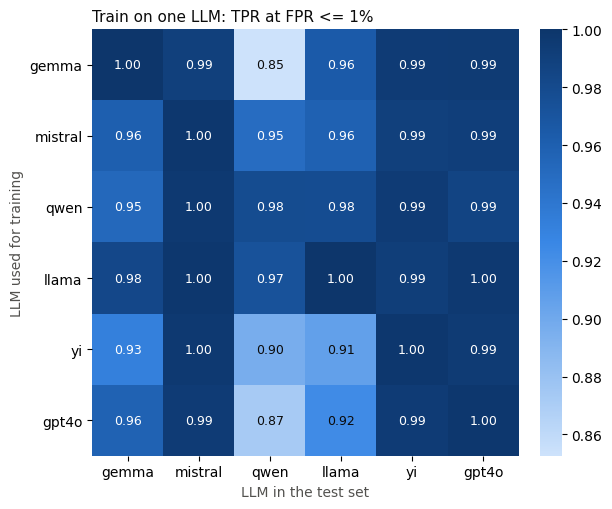

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# one-hue sequential ramp (light = low, dark = high)
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

def plot_matrix(m, title, fname):
    fig, ax = plt.subplots(figsize=(6.4, 5.2))
    vals = m.to_numpy(dtype=float)
    im = ax.imshow(vals, cmap=SEQ_BLUE, vmin=np.nanmin(vals), vmax=1.0)
    ax.set_xticks(range(len(m.columns)), m.columns)
    ax.set_yticks(range(len(m.index)), m.index)
    ax.set_xlabel("LLM in the test set", color=INK_MUTED)
    ax.set_ylabel("LLM used for training", color=INK_MUTED)
    mid = (np.nanmin(vals) + 1.0) / 2
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            ax.text(j, i, f"{vals[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if vals[i, j] > mid else INK)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(title, loc="left", fontsize=11, color=INK)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
    fig.tight_layout()
    os.makedirs("results", exist_ok=True)
    fig.savefig(f"results/{fname}", dpi=150)
    plt.show()

plot_matrix(tpr_matrix, "Train on one LLM: TPR at FPR <= 1%", "part4_train_one_tpr_matrix.png")

## 4.3 Input length

Same pipeline with shorter inputs: the first 25, 50, 100 or 200 words of each text. For every length:
- **seen, normalised:** Part 3 setting (all LLMs in training), normalised text;
- **seen, raw format:** same, on the raw-format copy (formatting kept), to measure the formatting shortcut away from the ceiling;
- **LOGO, normalised:** the six leave-one-generator-out folds; mean and worst fold are reported.

`C` is fixed at 10 (selected in Part 3) and τ is chosen on validation as before.

In [44]:
LENGTHS = [25, 50, 100, 200]
t0 = time.time()
length_rows = []
for L in LENGTHS:
    cut = lambda s: s.map(lambda t: first_n_words(t, L))
    cut_raw = lambda s: s.map(lambda t: first_n_words_keep_format(t, L))
    row = {"words": L}

    for name, col, cutter in [("seen_norm", "text_input", cut), ("seen_raw", "text_raw_input", cut_raw)]:
        vec, clf = fit_tfidf_lr_fixed(cutter(train_df[col]), train_df["label"])
        tau = threshold_at_fpr(val_df["label"].to_numpy(), lr_scores(vec, clf, cutter(val_df[col])))
        r = evaluate(test_df["label"], lr_scores(vec, clf, cutter(test_df[col])), tau)
        row[f"{name}_AUROC"], row[f"{name}_TPR@1%"] = r["AUROC"], r["TPR@FPR<=1%"]

    fold_auc, fold_tpr = [], []
    for held in GENERATORS:
        tr = train_df[train_df["source"] != held]
        vec, clf = fit_tfidf_lr_fixed(cut(tr["text_input"]), tr["label"])
        te = subset(test_df, ["human", held])
        s = lr_scores(vec, clf, cut(te["text_input"]))
        fold_auc.append(roc_auc_score(te["label"], s))
        fold_tpr.append(tpr_at_fpr(te["label"].to_numpy(), s))
    row["logo_AUROC_mean"], row["logo_AUROC_worst"] = np.mean(fold_auc), np.min(fold_auc)
    row["logo_TPR@1%_mean"], row["logo_TPR@1%_worst"] = np.mean(fold_tpr), np.min(fold_tpr)
    row["logo_worst_LLM"] = GENERATORS[int(np.argmin(fold_tpr))]
    length_rows.append(row)
    print(f"{L:>3} words done ({time.time() - t0:.0f}s)")

length_table = pd.DataFrame(length_rows).set_index("words")
length_table.round(4)

 25 words done (27s)
 50 words done (74s)
100 words done (163s)
200 words done (330s)


,seen_norm_AUROC,seen_norm_TPR@1%,seen_raw_AUROC,seen_raw_TPR@1%,logo_AUROC_mean,logo_AUROC_worst,logo_TPR@1%_mean,logo_TPR@1%_worst,logo_worst_LLM
words,,,,,,,,,
25,0.9849,0.7914,1.0000,0.9997,0.9798,0.9661,0.7442,0.5674,gemma
50,0.9965,0.9280,1.0000,1.0000,0.9946,0.9908,0.9009,0.8284,gemma
100,0.9992,0.9793,1.0000,0.9997,0.9981,0.9943,0.9627,0.9116,qwen
200,0.9996,0.9927,0.9999,0.9997,0.9992,0.9969,0.9856,0.9548,qwen


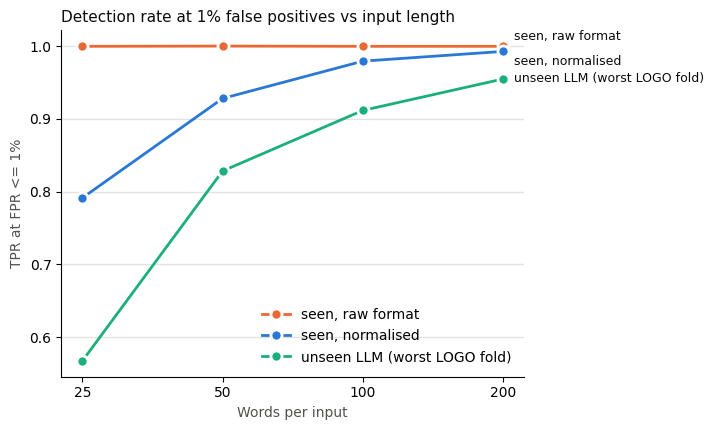

In [45]:
# (column, label, colour, vertical label offset in points so end labels do not collide)
SERIES = [("seen_raw_TPR@1%", "seen, raw format", "#eb6834", 7),
          ("seen_norm_TPR@1%", "seen, normalised", "#2a78d6", -7),
          ("logo_TPR@1%_worst", "unseen LLM (worst LOGO fold)", "#1baf7a", 0)]

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for col, label, color, dy in SERIES:
    ax.plot(LENGTHS, length_table[col], color=color, linewidth=2, marker="o", markersize=8,
            markeredgecolor="white", markeredgewidth=2, label=label)
    ax.annotate(label, (LENGTHS[-1], length_table[col].iloc[-1]), xytext=(8, dy),
                textcoords="offset points", va="center", fontsize=9, color=INK)
ax.set_xscale("log", base=2)
ax.set_xticks(LENGTHS, [str(L) for L in LENGTHS])
ax.set_xlabel("Words per input", color=INK_MUTED)
ax.set_ylabel("TPR at FPR <= 1%", color=INK_MUTED)
ax.grid(axis="y", color=GRID, linewidth=1)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Detection rate at 1% false positives vs input length", loc="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig("results/part4_length_ablation_tpr.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.4 Save results

In [46]:
logo_table.round(4).to_csv("results/part4_logo_tfidf.csv")
auc_matrix.round(4).to_csv("results/part4_train_one_auroc_matrix.csv")
tpr_matrix.round(4).to_csv("results/part4_train_one_tpr_matrix.csv")
length_table.round(4).to_csv("results/part4_length_ablation.csv")
print(sorted(os.listdir("results")))

['part3_baselines_test.csv', 'part3_tfidf_lr_per_generator_auroc.csv', 'part4_length_ablation.csv', 'part4_length_ablation_tpr.png', 'part4_logo_tfidf.csv', 'part4_train_one_auroc_matrix.csv', 'part4_train_one_tpr_matrix.csv', 'part4_train_one_tpr_matrix.png']


---

# Part 5: DistilBERT detector with a hand-written PyTorch training loop

**Why a second model?** TF-IDF + LR only sees *which* words and short phrases occur. A pretrained transformer reads the words **in context** (word order, sentence structure), so it may detect AI style that is not visible to a bag of words. Part 4 showed where TF-IDF struggles: **short inputs** and **unseen LLMs**. Those are the settings tested here.

**GPU runs in this part (Colab T4 recommended: Runtime > Change runtime type > T4 GPU):**

| Run | Training LLMs | Input | Compared with |
|---|---|---|---|
| seen_200 | all 6 | 200 words | Part 3 TF-IDF |
| seen_50 | all 6 | 50 words | TF-IDF at 50 words; reference for LOGO_50 |
| seen_25 | all 6 | 25 words | TF-IDF at 25 words |
| logo_50 (6 folds) | 5 (one held out) | 50 words | TF-IDF LOGO at 50 words |

Each finished run is saved to `results/`, and a run that already has a result file is skipped, so the notebook can be resumed if Colab disconnects.

## 5.0 Setup

In [47]:
!pip install -q transformers

import copy, math, json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert-base-uncased"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no GPU: training will be very slow")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Device: cuda | Tesla T4


## 5.1 Tokenizer and input length in tokens

DistilBERT does not read words, it reads **WordPiece tokens** (frequent words are one token; rare words are split, e.g. `detector` → `detect`, `##or`). Every input also gets a `[CLS]` token at the start and `[SEP]` at the end.

In Part 2 we assumed 200 words ≈ 256 tokens. Here we **measure** it and set the maximum sequence length per input length so that (almost) no text is truncated: the 99th percentile of token counts, rounded up to a multiple of 32 (maximum 512, DistilBERT's limit).

In [48]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

example = train_df["text_input"].iloc[0]
print("First 20 words :", " ".join(example.split()[:20]))
print("First 25 tokens:", tokenizer.convert_ids_to_tokens(tokenizer(example)["input_ids"][:25]), "\n")

sample = train_df["text_input"].sample(2000, random_state=SEED)
MAX_LEN = {}
rows = []
for L in [25, 50, 200]:
    n_tok = np.array([len(tokenizer(first_n_words(t, L))["input_ids"]) for t in sample])   # includes [CLS] and [SEP]
    MAX_LEN[L] = int(min(512, math.ceil(np.percentile(n_tok, 99) / 32) * 32))
    rows.append({"words": L, "median_tokens": np.median(n_tok), "p99_tokens": np.percentile(n_tok, 99),
                 "max_tokens": n_tok.max(), "MAX_LEN_used": MAX_LEN[L], "share_truncated": np.mean(n_tok > MAX_LEN[L])})
pd.DataFrame(rows).set_index("words").round(3)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

First 20 words : The U.S. bombings thatended World War II didn't mark theclose of atomic warfare.They were just the beginning. The U.S. bombingsthat
First 25 tokens: ['[CLS]', 'the', 'u', '.', 's', '.', 'bombings', 'that', '##ended', 'world', 'war', 'ii', 'didn', "'", 't', 'mark', 'the', '##cl', '##ose', 'of', 'atomic', 'warfare', '.', 'they', 'were'] 



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (941 > 512). Running this sequence through the model will result in indexing errors


,median_tokens,p99_tokens,max_tokens,MAX_LEN_used,share_truncated
words,,,,,
25,34.0,48.00,108,64,0.000
50,65.0,84.01,239,96,0.002
200,255.0,308.01,941,320,0.006


## 5.2 Data pipeline

`TextDataset` returns (text, label) pairs. The `collate` function tokenises a whole batch at once: it pads every sequence to the longest one in the batch and returns
- `input_ids` (batch × tokens): token indices,
- `attention_mask` (batch × tokens): 1 for real tokens, 0 for padding, so attention ignores the padding,
- `labels` (batch): 0 = human, 1 = AI.

In [49]:
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = list(texts), list(labels)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        return self.texts[i], self.labels[i]

def make_loader(texts, labels, max_len, batch_size, shuffle):
    def collate(batch):
        texts, labels = zip(*batch)
        enc = tokenizer(list(texts), padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        enc["labels"] = torch.tensor(labels, dtype=torch.float32)
        return enc
    return DataLoader(TextDataset(texts, labels), batch_size=batch_size, shuffle=shuffle, collate_fn=collate)

## 5.3 Model (hypothesis)

```
text → tokenizer → input_ids (B × T)
     → DistilBERT encoder (6 transformer layers, hidden size 768, ~66M pretrained parameters)
     → hidden states H (B × T × 768)
     → take the vector of the first token [CLS]: h = H[:, 0]  (B × 768)
     → dropout (p = 0.1)
     → linear layer: z = w·h + b   (768 weights + 1 bias, new, randomly initialised)
     → z is the logit;  P(AI) = sigmoid(z)
```

So the hypothesis class is: a pretrained encoder that maps a text to a 768-dimensional vector, followed by **the same kind of linear classifier as Logistic Regression in Part 3**. The difference is that the features `h` are learned and context-dependent, and during fine-tuning **all** encoder weights are updated too.

*Why the [CLS] vector?* The encoder was pretrained so that this position can summarise the sequence; it is the standard choice for sentence classification. An alternative is mean pooling over all tokens.

In [50]:
class DistilBertDetector(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)          # pretrained weights
        hidden = self.encoder.config.hidden_size                       # 768 for distilbert-base
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)                               # new, randomly initialised

    def forward(self, input_ids, attention_mask):
        H = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state  # (B, T, 768)
        h_cls = H[:, 0]                                                # (B, 768) vector of [CLS]
        z = self.head(self.dropout(h_cls)).squeeze(-1)                 # (B,) logit
        return z

## 5.4 Loss, optimiser and learning-rate schedule

**Loss: weighted binary cross-entropy on the logit** (`BCEWithLogitsLoss`):

`ℓ(z, y) = − [ w₊ · y · log σ(z) + (1 − y) · log(1 − σ(z)) ]`,   with `w₊ = n_human / n_AI`

- This is the **same criterion** as Logistic Regression in Part 3: the negative log-likelihood of a Bernoulli model, i.e. the cross-entropy between the true label distribution and the predicted `(1 − σ(z), σ(z))`.
- `w₊ < 1` down-weights the AI class (about 88% of the training data) so that both classes contribute equally to the total loss, the same idea as `class_weight="balanced"` in Part 3.
- Working on the logit `z` (instead of first computing σ(z) and then the log) is numerically stable.

**Optimiser: AdamW**, learning rate 2e-5, weight decay 0.01 (not applied to biases and LayerNorm weights).
- Adam keeps running averages of the gradient (`m`) and of the squared gradient (`v`) for every parameter and updates `θ ← θ − η · m̂ / (√v̂ + ε)`, so each parameter gets its own step size. AdamW applies weight decay directly to the weights instead of through the gradient.
- A small learning rate is used because the encoder is already pretrained: large steps would destroy what it learned (standard range for BERT fine-tuning is about 1e-5 to 5e-5).

**Schedule:** linear warm-up over the first 10% of steps (the new head starts random, so early gradients are noisy), then linear decay to 0.

**Other training details:** batch size 32, 2 epochs, gradient-norm clipping at 1.0, mixed precision on GPU. After each epoch the model is evaluated on the validation set and the epoch with the **best validation AUROC** is kept (model selection without touching the test set).

In [51]:
def make_optimizer(model, lr, weight_decay=0.01):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        (no_decay if (name.endswith("bias") or "LayerNorm" in name or "layer_norm" in name) else decay).append(p)
    return torch.optim.AdamW([{"params": decay, "weight_decay": weight_decay},
                              {"params": no_decay, "weight_decay": 0.0}], lr=lr)

def linear_warmup_decay(optimizer, total_steps, warmup_frac=0.1):
    warmup = max(1, int(warmup_frac * total_steps))
    def factor(step):
        if step < warmup:
            return (step + 1) / warmup                                   # 0 -> 1 during warm-up
        return max(0.0, (total_steps - step) / max(1, total_steps - warmup))   # 1 -> 0 afterwards
    return torch.optim.lr_scheduler.LambdaLR(optimizer, factor)

@torch.no_grad()
def predict_logits(model, texts, max_len, batch_size=128):
    model.eval()
    loader = make_loader(texts, [0] * len(texts), max_len, batch_size, shuffle=False)
    out = []
    for batch in loader:
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
            z = model(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE))
        out.append(z.float().cpu().numpy())
    return np.concatenate(out)

## 5.5 Training loop

One step of the loop is exactly the learning algorithm from the course:
1. **forward:** compute logits `z = f_θ(x)` for a batch;
2. **loss:** `L(θ)` = mean weighted BCE over the batch;
3. **backward:** `loss.backward()` computes `∇θ L` for all ~66M parameters by back-propagation;
4. **clip:** rescale the gradient if its norm exceeds 1.0 (protects against rare very large updates);
5. **step:** AdamW updates θ; the scheduler updates the learning rate.

In [52]:
def train_detector(tr_texts, tr_labels, va_texts, va_labels, max_len, epochs=2, lr=2e-5,
                   batch_size=32, seed=SEED, verbose=True):
    set_seed(seed)
    model = DistilBertDetector().to(DEVICE)
    tr_labels, va_labels = np.asarray(tr_labels), np.asarray(va_labels)

    pos_weight = torch.tensor((tr_labels == 0).sum() / (tr_labels == 1).sum(), device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loader = make_loader(tr_texts, tr_labels, max_len, batch_size, shuffle=True)
    optimizer = make_optimizer(model, lr)
    scheduler = linear_warmup_decay(optimizer, total_steps=epochs * len(loader))
    scaler = torch.amp.GradScaler(enabled=DEVICE.type == "cuda")

    history, step_losses, best = [], [], {"auroc": -1}
    for epoch in range(1, epochs + 1):
        model.train()
        t0, running = time.time(), 0.0
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            y = batch["labels"].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
                z = model(ids, mask)                                   # 1) forward
                loss = loss_fn(z.float(), y)                           # 2) loss
            scaler.scale(loss).backward()                              # 3) backward
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 4) clip
            scaler.step(optimizer); scaler.update(); scheduler.step() # 5) update
            step_losses.append(loss.item()); running += loss.item()

        va_z = predict_logits(model, va_texts, max_len)
        va_auroc = roc_auc_score(va_labels, va_z)
        va_loss = loss_fn(torch.tensor(va_z, device=DEVICE), torch.tensor(va_labels, dtype=torch.float32, device=DEVICE)).item()
        history.append({"epoch": epoch, "train_loss": running / len(loader), "val_loss": va_loss,
                        "val_AUROC": va_auroc, "minutes": (time.time() - t0) / 60})
        if verbose:
            print(f"  epoch {epoch}: train loss {history[-1]['train_loss']:.4f} | val loss {va_loss:.4f} "
                  f"| val AUROC {va_auroc:.4f} | {history[-1]['minutes']:.1f} min")
        if va_auroc > best["auroc"]:                                   # keep the best epoch (by validation)
            best = {"auroc": va_auroc, "epoch": epoch, "va_z": va_z,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}

    model.load_state_dict(best["state"])
    tau = threshold_at_fpr(va_labels, best["va_z"])
    return model, pd.DataFrame(history), tau, step_losses, best["epoch"]

## 5.6 Run the experiments

`run_experiment` trains one model, chooses τ on its validation set, evaluates on its test set, saves the metrics and the test scores (used for error analysis in Part 6), and frees GPU memory. If the result file already exists, the run is skipped and the saved result is loaded.

In [53]:
os.makedirs("results/part5", exist_ok=True)

def run_experiment(name, words, train_sources, test_sources, epochs=2):
    path = f"results/part5/{name}.json"
    if os.path.exists(path):
        print(f"[{name}] already done, loading saved result")
        return json.load(open(path))
    print(f"[{name}] training on {train_sources}, {words} words, MAX_LEN={MAX_LEN[words]}")
    tr, va, te = subset(train_df, train_sources), subset(val_df, train_sources), subset(test_df, test_sources)
    cut = lambda s: [first_n_words(t, words) for t in s]
    t0 = time.time()
    model, hist, tau, step_losses, best_epoch = train_detector(
        cut(tr["text_input"]), tr["label"], cut(va["text_input"]), va["label"], MAX_LEN[words], epochs=epochs)
    te_z = predict_logits(model, cut(te["text_input"]), MAX_LEN[words])
    res = evaluate(te["label"], te_z, tau)
    out = {"name": name, "words": words, "train_sources": train_sources, "best_epoch": best_epoch,
           "minutes_total": (time.time() - t0) / 60, "test": res,
           "per_generator_AUROC": per_generator_auroc(te, te_z, [g for g in GENERATORS if g in test_sources]).to_dict(),
           "history": hist.to_dict(orient="records"), "step_losses": step_losses[::10]}
    pd.DataFrame({"index": te.index, "source": te["source"].values, "label": te["label"].values, "score": te_z}
                 ).to_csv(f"results/part5/{name}_test_scores.csv", index=False)
    json.dump(out, open(path, "w"), default=float)
    del model; torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    print(f"[{name}] test AUROC {res['AUROC']:.4f} | TPR@1% {res['TPR@FPR<=1%']:.4f} | {out['minutes_total']:.1f} min total\n")
    return out

ALL = ["human"] + GENERATORS
part5 = {}
part5["seen_200"] = run_experiment("seen_200", 200, ALL, ALL)

[seen_200] training on ['human', 'gemma', 'mistral', 'qwen', 'llama', 'yi', 'gpt4o'], 200 words, MAX_LEN=320


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: train loss 0.0215 | val loss 0.0039 | val AUROC 1.0000 | 4.0 min
  epoch 2: train loss 0.0013 | val loss 0.0030 | val AUROC 1.0000 | 3.9 min
[seen_200] test AUROC 0.9998 | TPR@1% 0.9994 | 8.2 min total



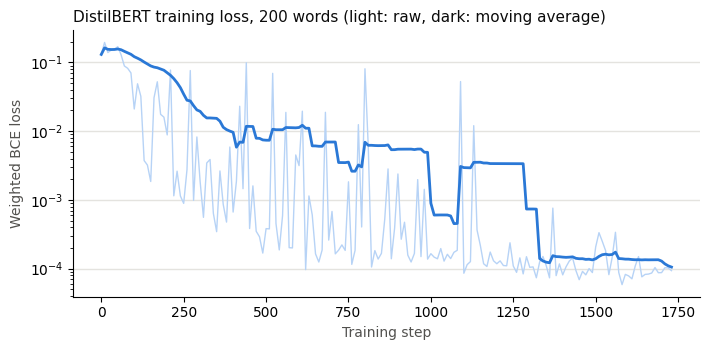

,epoch,train_loss,val_loss,val_AUROC,minutes
0,1,0.0215,0.0039,1.0,4.0112
1,2,0.0013,0.0030,1.0,3.8713


In [54]:
# Training curve of the 200-word run (loss recorded every 10 steps)
losses = pd.Series(part5["seen_200"]["step_losses"])
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(np.arange(len(losses)) * 10, losses, color="#b7d3f6", linewidth=1)
ax.plot(np.arange(len(losses)) * 10, losses.rolling(20, min_periods=1).mean(), color="#2a78d6", linewidth=2)
ax.set_xlabel("Training step", color=INK_MUTED)
ax.set_ylabel("Weighted BCE loss", color=INK_MUTED)
ax.set_yscale("log")
ax.grid(axis="y", color=GRID, linewidth=1)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title("DistilBERT training loss, 200 words (light: raw, dark: moving average)", loc="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig("results/part5_training_loss_seen_200.png", dpi=150)
plt.show()
pd.DataFrame(part5["seen_200"]["history"]).round(4)

In [55]:
part5["seen_50"] = run_experiment("seen_50", 50, ALL, ALL)
part5["seen_25"] = run_experiment("seen_25", 25, ALL, ALL)
for held in GENERATORS:
    train_sources = [s for s in ALL if s != held]
    part5[f"logo_50_{held}"] = run_experiment(f"logo_50_{held}", 50, train_sources, ["human", held])

[seen_50] training on ['human', 'gemma', 'mistral', 'qwen', 'llama', 'yi', 'gpt4o'], 50 words, MAX_LEN=96


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: train loss 0.0311 | val loss 0.0112 | val AUROC 0.9997 | 1.3 min
  epoch 2: train loss 0.0040 | val loss 0.0085 | val AUROC 0.9998 | 1.3 min
[seen_50] test AUROC 0.9999 | TPR@1% 0.9987 | 2.7 min total

[seen_25] training on ['human', 'gemma', 'mistral', 'qwen', 'llama', 'yi', 'gpt4o'], 25 words, MAX_LEN=64


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: train loss 0.0343 | val loss 0.0136 | val AUROC 0.9997 | 1.1 min
  epoch 2: train loss 0.0038 | val loss 0.0097 | val AUROC 0.9998 | 1.1 min
[logo_50_yi] test AUROC 0.9999 | TPR@1% 0.9980 | 2.3 min total

[logo_50_gpt4o] training on ['human', 'gemma', 'mistral', 'qwen', 'llama', 'yi'], 50 words, MAX_LEN=96


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: train loss 0.0374 | val loss 0.0100 | val AUROC 0.9996 | 1.1 min
  epoch 2: train loss 0.0036 | val loss 0.0143 | val AUROC 0.9995 | 1.1 min
[logo_50_gpt4o] test AUROC 0.9999 | TPR@1% 0.9964 | 2.3 min total



## 5.7 DistilBERT vs TF-IDF + LR

The TF-IDF numbers for 50-word leave-one-generator-out are recomputed here per fold (Part 4 only stored the mean and worst fold), with the same settings as Part 4.3.

In [56]:
# Seen setting: all LLMs in training
seen_cmp = pd.DataFrame({
    "TF-IDF AUROC": [length_table.loc[200, "seen_norm_AUROC"], length_table.loc[50, "seen_norm_AUROC"], length_table.loc[25, "seen_norm_AUROC"]],
    "DistilBERT AUROC": [part5[k]["test"]["AUROC"] for k in ["seen_200", "seen_50", "seen_25"]],
    "TF-IDF TPR@1%": [length_table.loc[200, "seen_norm_TPR@1%"], length_table.loc[50, "seen_norm_TPR@1%"], length_table.loc[25, "seen_norm_TPR@1%"]],
    "DistilBERT TPR@1%": [part5[k]["test"]["TPR@FPR<=1%"] for k in ["seen_200", "seen_50", "seen_25"]],
    "DistilBERT recall@tau": [part5[k]["test"]["recall_AI_at_tau"] for k in ["seen_200", "seen_50", "seen_25"]],
    "DistilBERT test FPR@tau": [part5[k]["test"]["test_FPR_at_tau"] for k in ["seen_200", "seen_50", "seen_25"]],
}, index=pd.Index([200, 50, 25], name="words"))
seen_cmp.round(4)

,TF-IDF AUROC,DistilBERT AUROC,TF-IDF TPR@1%,DistilBERT TPR@1%,DistilBERT recall@tau,DistilBERT test FPR@tau
words,,,,,,
200,0.9996,0.9998,0.9927,0.9994,0.9990,0.0095
50,0.9965,0.9999,0.9280,0.9987,0.9943,0.0047
25,0.9849,0.9980,0.7914,0.9449,0.9134,0.0047


In [57]:
# Leave-one-generator-out at 50 words
cut50 = lambda s: s.map(lambda t: first_n_words(t, 50))
seen50_scores = pd.read_csv("results/part5/seen_50_test_scores.csv").set_index("index")["score"]
rows = []
for held in GENERATORS:
    tr = train_df[train_df["source"] != held]
    vec, clf = fit_tfidf_lr_fixed(cut50(tr["text_input"]), tr["label"])
    te = subset(test_df, ["human", held])
    s_tfidf = lr_scores(vec, clf, cut50(te["text_input"]))
    s_seen = seen50_scores.loc[te.index].to_numpy()
    rows.append({"held_out": held,
                 "TF-IDF TPR@1% unseen": tpr_at_fpr(te["label"].to_numpy(), s_tfidf),
                 "DistilBERT TPR@1% seen": tpr_at_fpr(te["label"].to_numpy(), s_seen),
                 "DistilBERT TPR@1% unseen": part5[f"logo_50_{held}"]["test"]["TPR@FPR<=1%"],
                 "TF-IDF AUROC unseen": roc_auc_score(te["label"], s_tfidf),
                 "DistilBERT AUROC unseen": part5[f"logo_50_{held}"]["test"]["AUROC"],
                 "DistilBERT recall@tau unseen": part5[f"logo_50_{held}"]["test"]["recall_AI_at_tau"],
                 "DistilBERT test FPR@tau unseen": part5[f"logo_50_{held}"]["test"]["test_FPR_at_tau"]})
logo50_cmp = pd.DataFrame(rows).set_index("held_out")
logo50_cmp["DistilBERT TPR drop"] = logo50_cmp["DistilBERT TPR@1% seen"] - logo50_cmp["DistilBERT TPR@1% unseen"]
logo50_cmp.loc["mean"] = logo50_cmp.mean()
logo50_cmp.round(4)

,TF-IDF TPR@1% unseen,DistilBERT TPR@1% seen,DistilBERT TPR@1% unseen,TF-IDF AUROC unseen,DistilBERT AUROC unseen,DistilBERT recall@tau unseen,DistilBERT test FPR@tau unseen,DistilBERT TPR drop
held_out,,,,,,,,
gemma,0.8284,0.9965,0.9930,0.9908,0.9996,0.9842,0.0095,0.0035
mistral,0.9823,1.0000,1.0000,0.9990,1.0000,1.0000,0.0071,0.0000
qwen,0.8291,0.9961,0.9882,0.9910,0.9992,0.9804,0.0047,0.0079
llama,0.9084,1.0000,0.9801,0.9947,0.9992,0.9781,0.0095,0.0199
yi,0.9283,1.0000,0.9980,0.9963,0.9999,0.9959,0.0047,0.0020
gpt4o,0.9287,1.0000,0.9964,0.9956,0.9999,0.9964,0.0071,0.0036
mean,0.9009,0.9988,0.9926,0.9946,0.9996,0.9892,0.0071,0.0061


In [58]:
seen_cmp.round(4).to_csv("results/part5_seen_comparison.csv")
logo50_cmp.round(4).to_csv("results/part5_logo50_comparison.csv")
pd.DataFrame({k: v["test"] for k, v in part5.items()}).T.round(4).to_csv("results/part5_all_runs_test.csv")
pd.DataFrame({k: {"best_epoch": v["best_epoch"], "minutes": v["minutes_total"]} for k, v in part5.items()}).T.round(2)

,best_epoch,minutes
seen_200,2.0,8.21
seen_50,2.0,2.70
seen_25,2.0,1.92
logo_50_gemma,2.0,2.24
logo_50_mistral,2.0,2.30
logo_50_qwen,2.0,2.29
logo_50_llama,2.0,2.29
logo_50_yi,2.0,2.33
logo_50_gpt4o,1.0,2.25
